<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/AI%E3%81%AE%E3%81%9F%E3%82%81%E3%81%AEPython%E5%85%A5%E9%96%80Level2_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # <font color=#0e89b2>1. Level2でのゴール</font>

引き続き、新型コロナウィルスの感染拡大シミュレーションモデルの実装を行なっていきましょう。<br>
Level2では、1人のエージェントが街の中を規則的に行ったり来たりする動きを実装します。<br>
<br>
以下のコードを実行してみてください。

In [ ]:
#このコードは難読化されています
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random
gpz, gqo, ajg = 20, 40, {"hxr": 8, "rnh": 6, "mbf": 1, "ane": 1}
xgg, rbd = plt.subplots(figsize=(6, 6))

def nqm(ajg):
    for k, d in [('hxr', 'mbf'), ('rnh', 'ane')]:
        ajg[k] += ajg[d]
        if ajg[k] <= 0 or ajg[k] >= gpz: ajg[d] *= -1
    return ajg

def uan(frame):
    global ajg
    nqm(ajg)
    rbd.clear(), rbd.set(xlim=(0, gpz), ylim=(0, gpz)), rbd.scatter(ajg["hxr"], ajg["rnh"], s=10, color="blue", alpha=0.5)

ani = FuncAnimation(xgg, uan, frames=range(gqo), interval=100)
plt.close()

HTML(ani.to_jshtml())

またこの実装の過程で、以下のようなPythonの基本文法も学んでいきます。
* 辞書
* 条件分岐
* 論理演算

※使用するライブラリは、ここでまとめてインポートすることができます。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random

 # <font color=#0e89b2>2. 人を歩かせる</font>

 ## <font color=#0e89b2>2.1 まずは1マス歩かせる</font>

 ### <font color=#0e89b2>(1) 辞書</font>

ここでは「辞書」という概念を学びます。<br>
辞書を使うと、下の図のように、複数のデータをキーと値のペアで管理できるようになります。

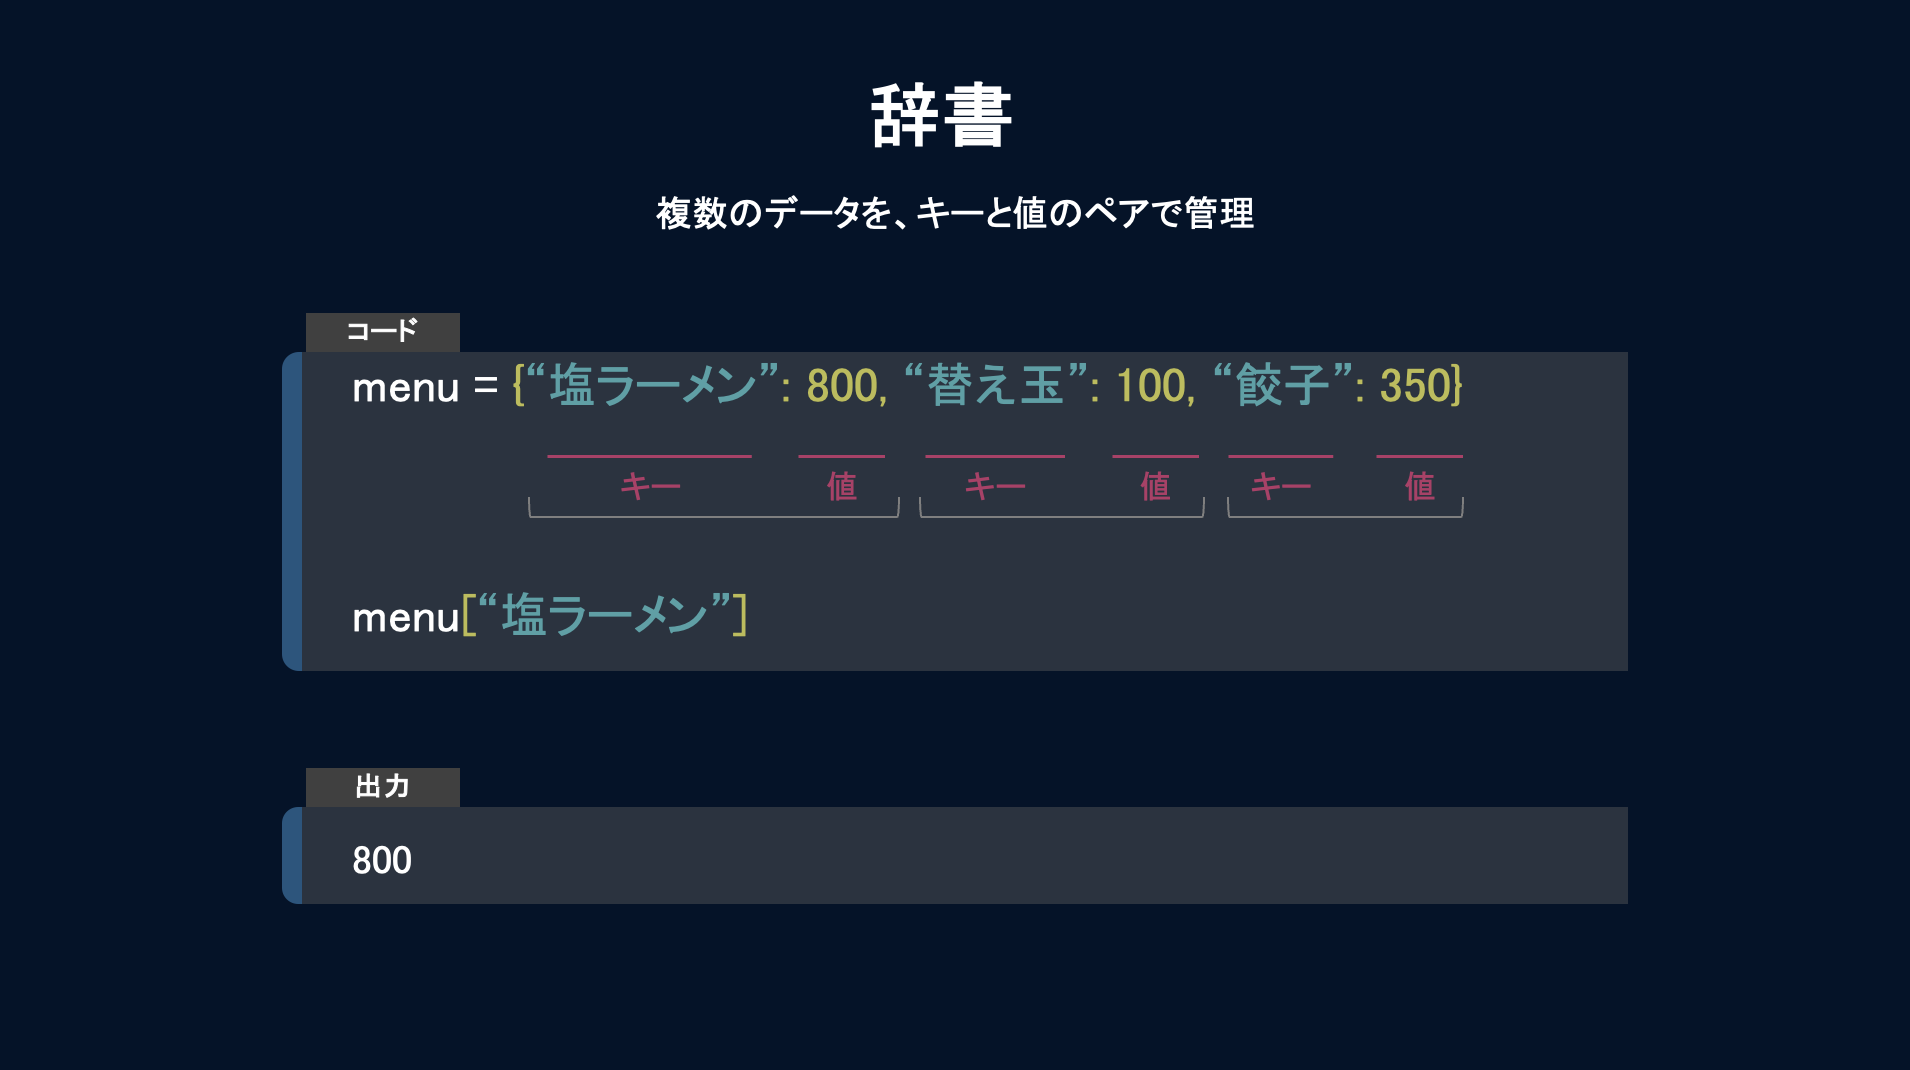

In [ ]:
#####写経#####
menu = {"塩ラーメン": 800, "替え玉": 100, "餃子": 350}
menu

{'塩ラーメン': 800, '替え玉': 100, '餃子': 350}

`辞書名[キー名]`でキーの名前を指定すると、そのキーに対応した値を取り出すことができます。

In [ ]:
#####写経#####
menu["塩ラーメン"]

800

`辞書名.keys()`で、その辞書に含まれるキーの一覧を取得できます。

In [ ]:
#####写経#####
menu.keys()

dict_keys(['塩ラーメン', '替え玉', '餃子'])

同様に`辞書名.values()`で、その辞書に含まれ値の一覧を取得できます。

In [ ]:
#####写経#####
menu.values()

dict_values([800, 100, 350])

リストの時と同様、辞書の中身も書き換えることができます。<br>
塩ラーメンを値下げしてみます。

In [ ]:
#####写経#####
menu["塩ラーメン"] = 700

 ### <font color=#0e89b2>◆練習問題</font>

(1) 以下の科目名をキー、点数を値とする辞書を作成してください。<br>
科目名は文字列、点数は数値で辞書を作成しましょう。
* 英語：87 (点)
* 数学：56 (点)
* 国語：15 (点)

(2) 各科目の合計点を計算してください。<br>
方法h(1)で作成した辞書の`values`

(3) 辞書とfor文を使って、以下のような文章を出力させてください。<br>

> 英語は87点でした<br>
> 数学は56点でした<br>
> 国語は15点でした

解答

(1)

In [ ]:
scores = {"英語": 87, "数学": 56, "国語": 15}
scores

{'英語': 87, '数学': 56, '国語': 15}

(2)

In [ ]:
sum(scores.values())

158

(3)

In [ ]:
for key in scores.keys():
  print(key, "は", scores[key], "点でした")

英語 は 87 点でした
数学 は 56 点でした
国語 は 15 点でした


 ### <font color=#0e89b2>◆実装</font>

それでは実装に入っていきましょう。<br>
ここではまずはエージェントを一歩だけ歩かせてみます。<br>
<br>
さてここで、エージェントにどのような法則で移動させるかを確認しておきましょう。

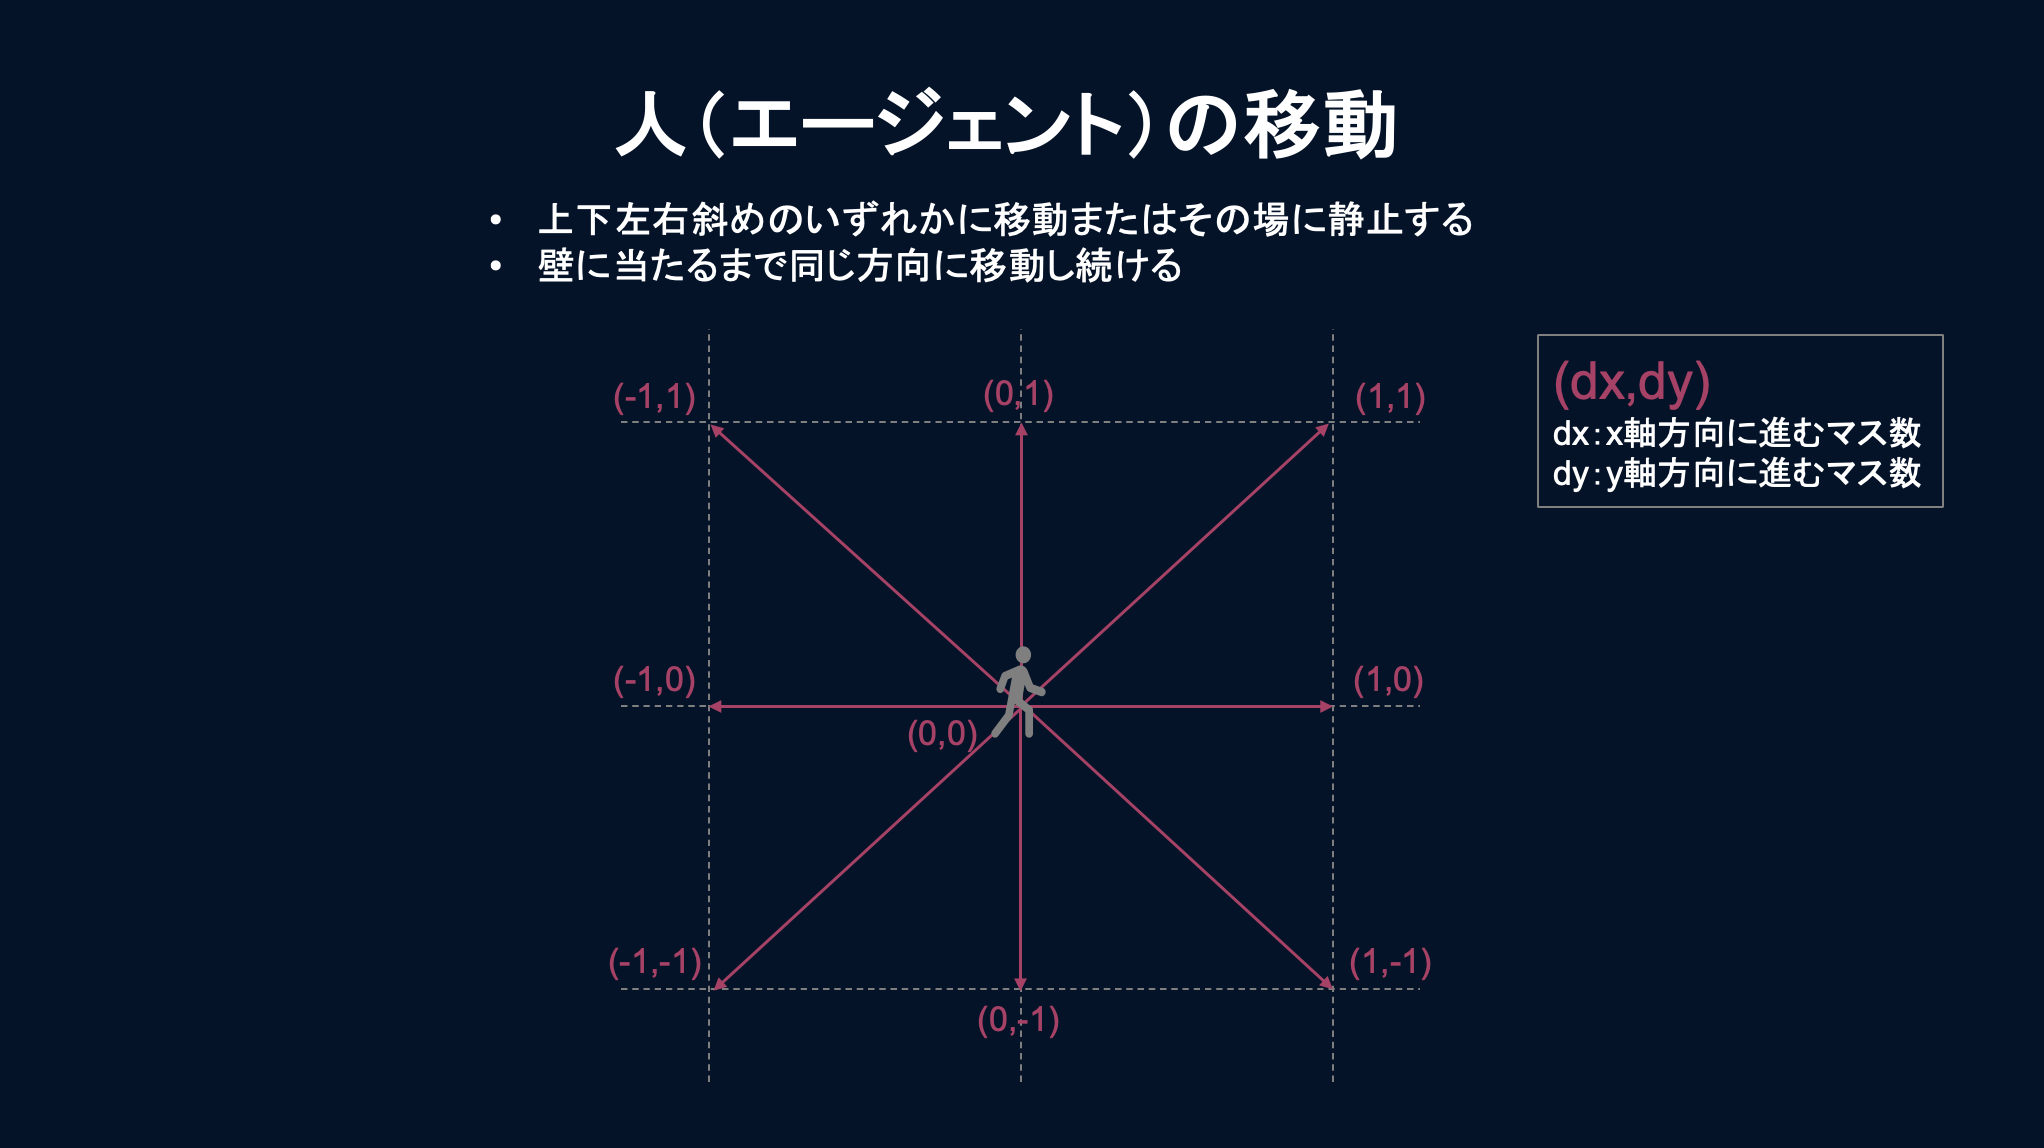

図のようにエージェントは、上下左右斜めのいずれかの方向に1マスずつ（斜めの場合は「1マス」というのか悩ましいですが）移動するか、<br>
またはその場で静止することにします。<br>
<br>
どの方向に進むかは、エージェントごとに下記の値を`[-1,0,1]`の中からランダムで決めて、その出目に従うことにします。
* dx：-1なら左に進む。1なら右に進む。0なら横方向には動かない。
* dy：-1なら下に進む。1なら上に進む。0なら上下方向には動かない。

例えばエージェントAは`dx=0`、`dy=1`がランダムで出たとすると、壁に当たるまでひたすら上方向に移動し続けます。<br>
また別のエージェントBは`dx=0`,`dy=0`がランダムで出たとすると、その場に静止し続けます。

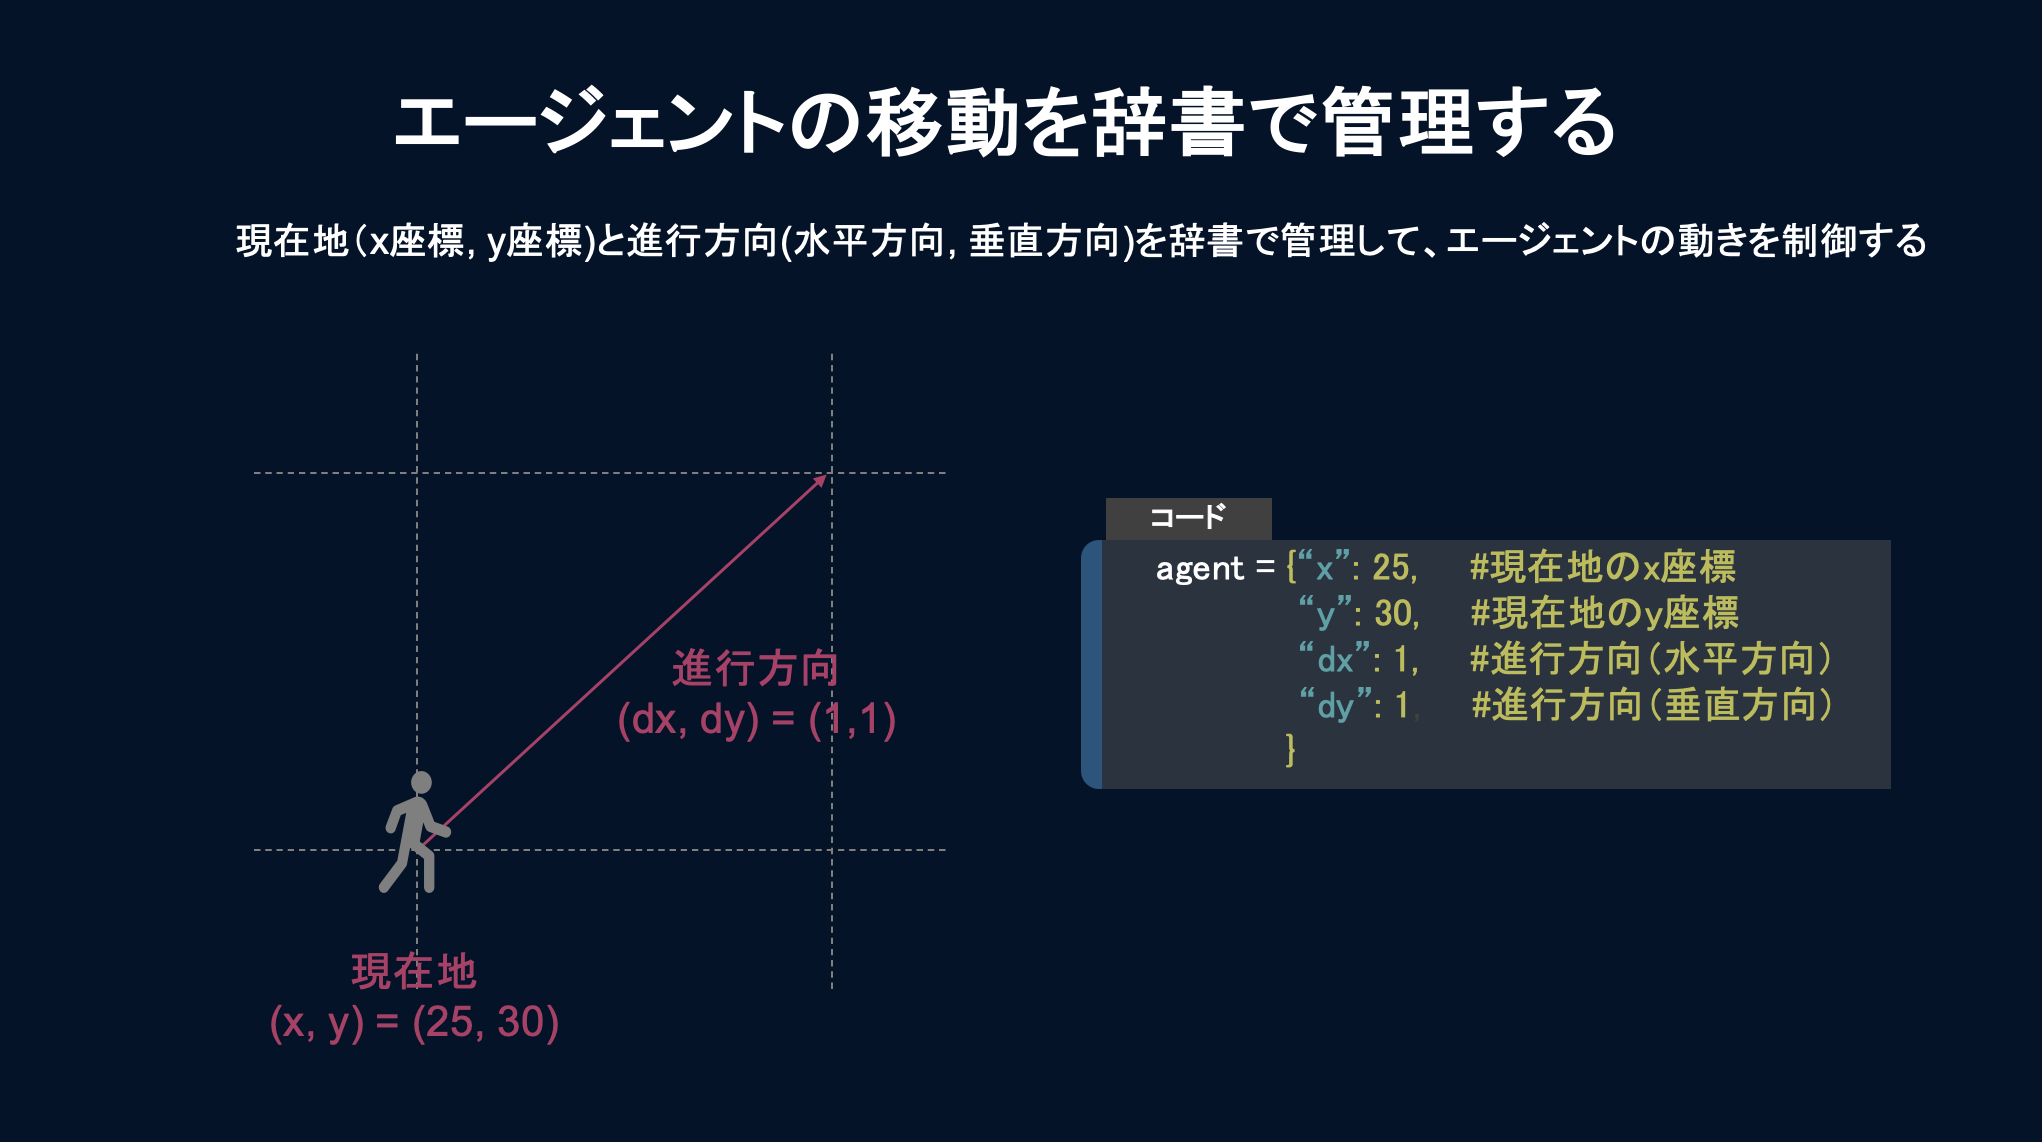

それではエージェントの移動をプログラミングでどのように制御するのが良いでしょうか。<br>
今回は図のように、エージェントごとに辞書を作成し、現在地(x座標, y座標)と進行方向(水平方向, 垂直方向)の情報を持たせます。<br>
<br>
この辞書の値を操作することによって、エージェントの動きを制御することにします。
* 例えば、エージェントが右に1マス進んだ場合は、`agent["x"]`を+1します
* 例えば、上向きに進んでいたエージェントを下向きに方向転換させたい場合は、`agent["dy"]`に-1を掛けます


(1) まずはあるエージェント一人分の辞書`agent`を作成しましょう。<br>
辞書に含まれるキーは以下の通りです。
* `"x"`：現在地のx座標
* `"y"`：現在地のy座標
* `"dx"`：進行方向（水平方向）
* `"dy"`：進行方向（垂直方向）
<br>

また値は下記のように決定してください。
* `"x"`：0から`grid_size`の中からランダムに決定
* `"y"`：0から`grid_size`の中からランダムに決定
* `"dx"`：`[-1,0,1]`の中からランダムに決定
* `"dy"`：`[-1,0,1]`の中からランダムに決定

(2) (1)で作成したエージェントの現在地を描画してください。

(3) 次の進行先のマスのx座標を`next_x`、y座標を`next_y`として、それぞれ値を計算してください。<br>


(4) 移動前の位置を移動後の位置を、1つのキャンバスに両方描画してください。<br>
こちらの図が完成イメージです。

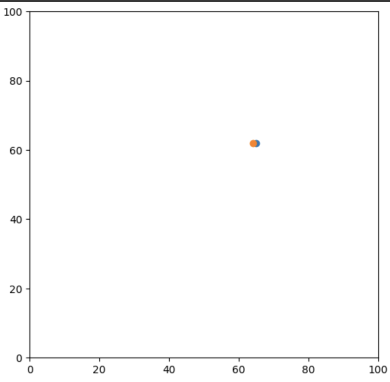

実装例

(1)

In [ ]:
import random
grid_size = 100

agent = {}
agent["x"] = random.randint(0, grid_size)
agent["y"] = random.randint(0, grid_size)
agent["dx"] = random.choice([-1, 0, 1])
agent["dy"] = random.choice([-1, 0, 1])

agent

{'x': 65, 'y': 62, 'dx': 1, 'dy': 0}

(2)

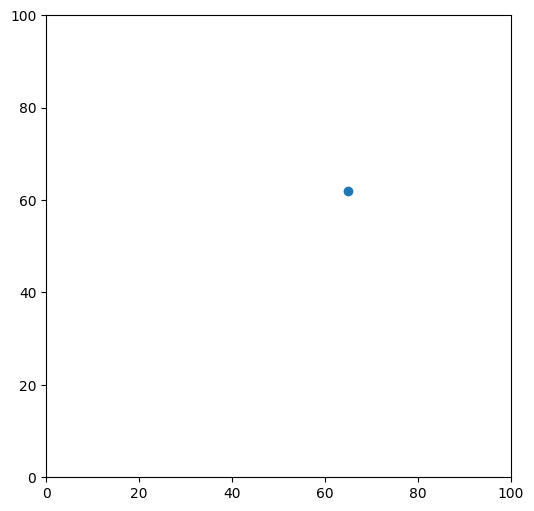

In [ ]:
plt.figure(figsize=(6,6))
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)

plt.scatter(agent["x"], agent["y"])

(3)

In [ ]:
next_x = agent['x'] + agent['dx']
next_y = agent['y'] + agent['dy']

(4)

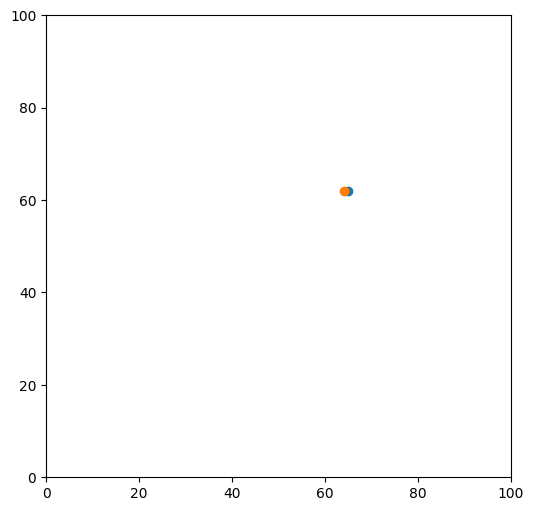

In [ ]:
plt.figure(figsize=(6,6))
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)
plt.scatter(agent["x"], agent["y"])
plt.scatter(next_x, next_y)

このコードのように、`plt.scatter()`関数を連続して2回実行する方法でも、複数の点を散布図で描画できます。

 ## <font color=#0e89b2>2.2 10マス歩かせる</font>

 ### <font color=#0e89b2>◆練習問題</font>

ひどいハイパーインフレーションで、毎年物価が20%ずつ上がっていきます。<br>
0年目では800円だったラーメンが、毎年いくらに値上がっていくかを出力してください。<br>
<br>
出力形式は、以下のような文章とします。

> 1年目はXX円でした<br>
2年目はXX円でした<br>
3年目はXX円でした<br>
（続く）

条件
* ラーメンの価格は、変数`price`に格納してください。
* 物価上昇率は、変数`rate`に格納してください。
* 出力結果は`round()`関数を使って小数点以下を丸めておきましょう。



解答

In [ ]:
price = 800
rate = 1.2
for year in range(10):
  price *= rate
  print(year+1, "年目は", round(price), "円でした")

1 年目は 960 円でした
2 年目は 1152 円でした
3 年目は 1382 円でした
4 年目は 1659 円でした
5 年目は 1991 円でした
6 年目は 2389 円でした
7 年目は 2867 円でした
8 年目は 3440 円でした
9 年目は 4128 円でした
10 年目は 4953 円でした


 ### <font color=#0e89b2>◆実装</font>

エージェントを10マス分歩かせて、その移動経路をキャンバスに描画してください。<br>
条件
* 歩かせるマス数は、`steps`という変数に格納しましょう。
* エージェントの現在地や進行方向を管理する辞書は、2.1で実装した`agent`辞書を流用しましょう。
* `agent`辞書の中の`agent["x"]`と`agent["y"]`を、移動するたびに書き換えましょう。
 * つまり、常に辞書内の現在地情報がアップデートされる形になります。

<br>

完成イメージは下の図です。<br>
※`random`を使っているので、毎回出力結果が異なります。何回か実行してみてください。

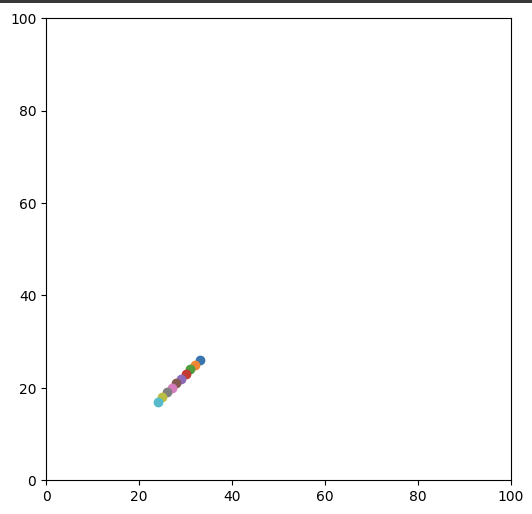

実装例

In [ ]:
grid_size = 100

agent = {}
agent["x"] = random.randint(1, grid_size-1)
agent["y"] = random.randint(1, grid_size-1)
agent["dx"] = random.choice([-1, 0, 1])
agent["dy"] = random.choice([-1, 0, 1])

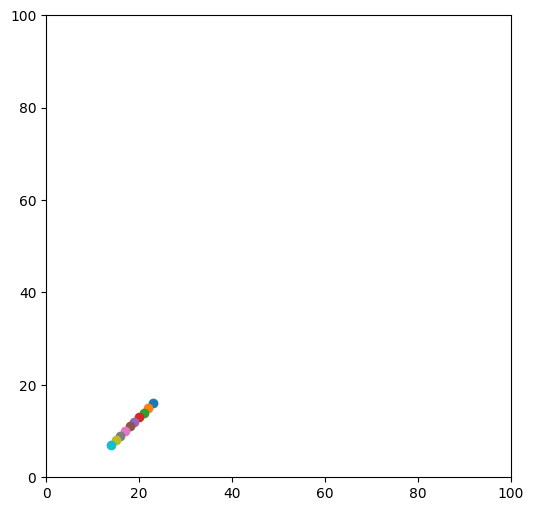

In [ ]:
plt.figure(figsize=(6,6))
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)

steps = 10
for i in range(steps):
  #移動
  agent['x'] += agent['dx']
  agent['y'] += agent['dy']

  #描画
  plt.scatter(agent["x"], agent["y"])

 ## <font color=#0e89b2>2.3 壁に当たったら方向転換させる</font>

 ### <font color=#0e89b2>(1) 条件分岐</font>

ここではまず条件分岐の書き方を学びます。<br>
一番基本的な条件分岐の書き方はこちらです。

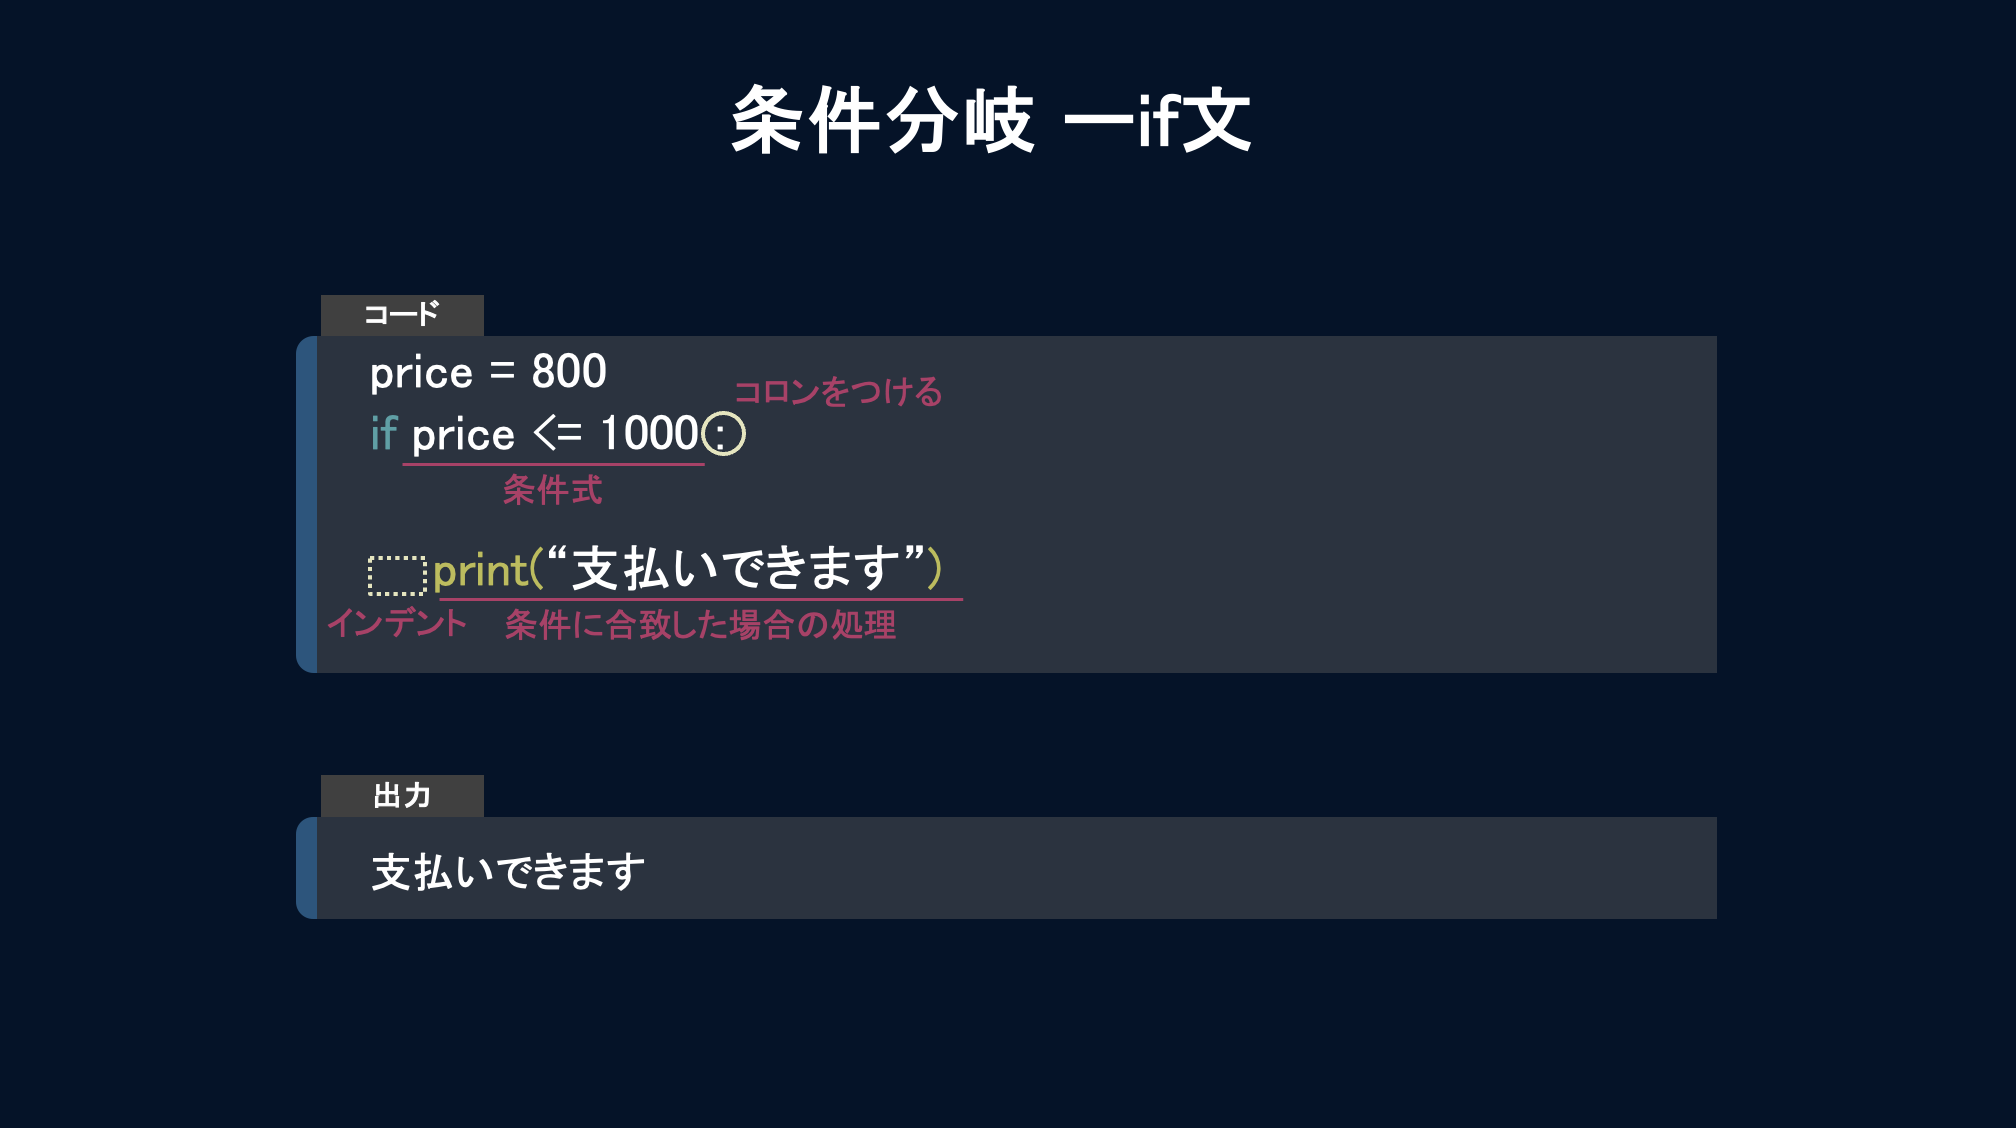

In [ ]:
#####写経#####
price = 800
if  price <= 1000:
  print("支払いできます")

支払いできます


この条件の判定の部分でよく使われるのが、「比較演算子」です。

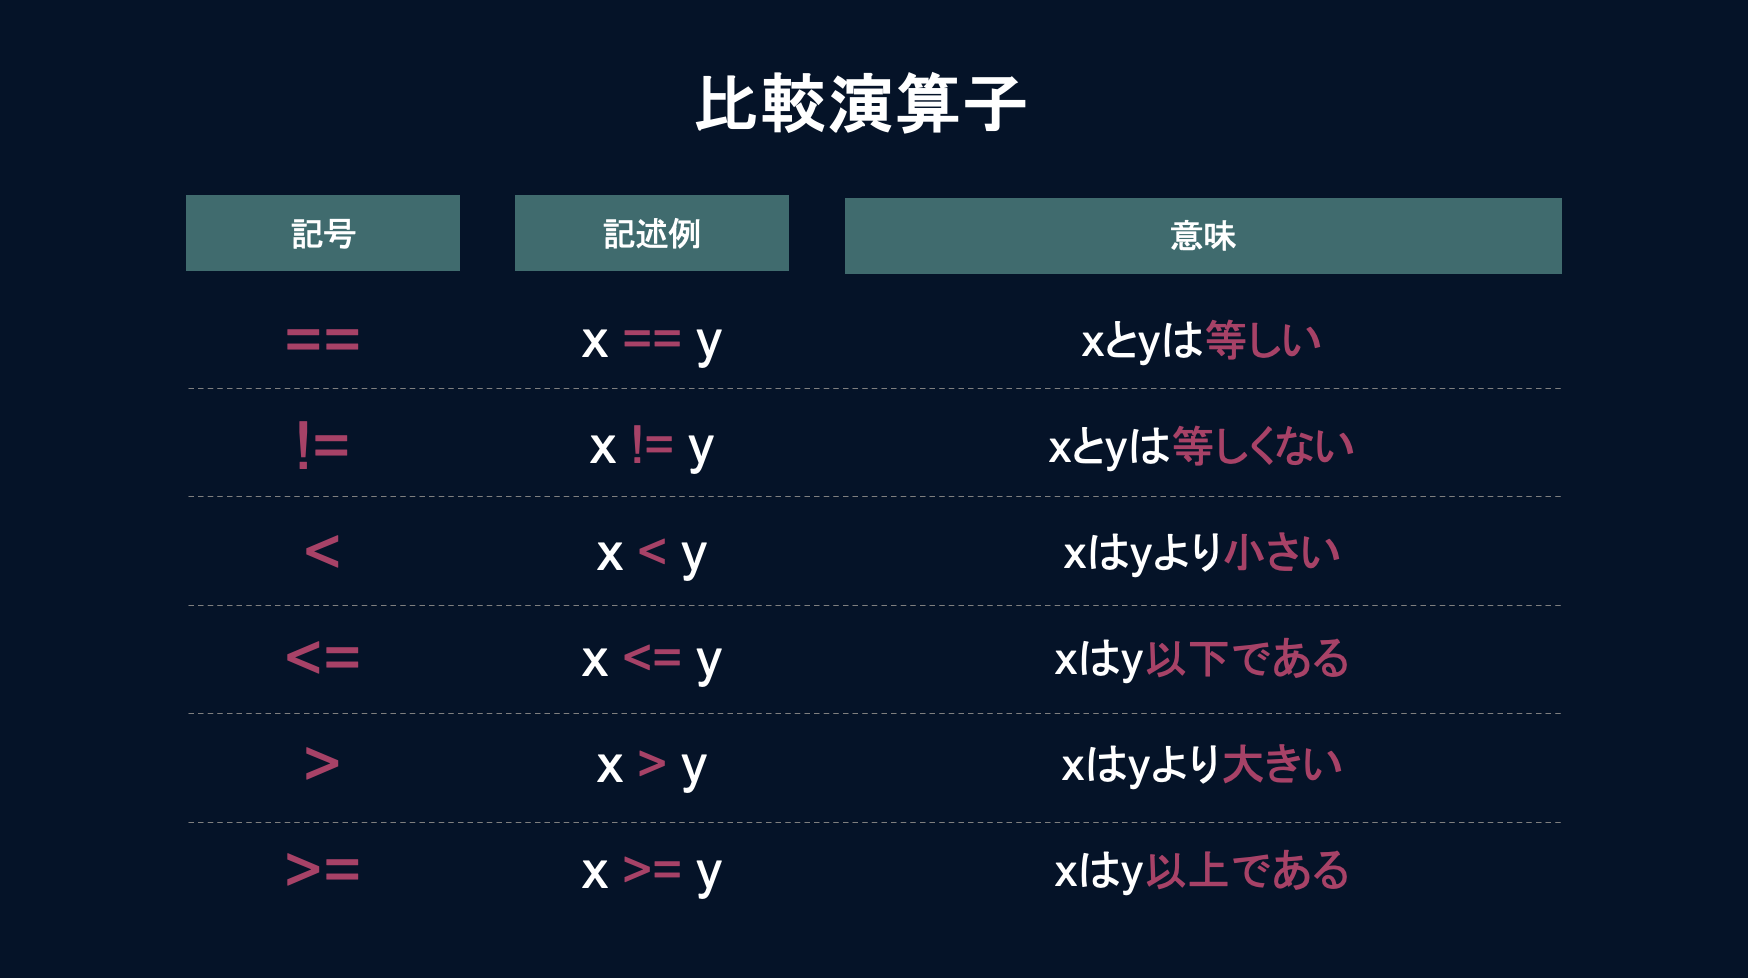

比較演算子の挙動を確認しておきましょう。

In [ ]:
#####写経#####
10 == 25

False

In [ ]:
#####写経#####
34 > 29

True

このように、正しければ`True`、正しくなければ`False`の値を返します。<br>
if文も、`if (条件式):`で条件式の計算結果が`True`であれば、下の処理を行うという仕組みになっています。

In [ ]:
#####写経#####
if True:
  print("Trueです")

Trueです


論理演算子以外でも、条件式は`True`または`False`を返すものであれば何でもOKです。<br>
例えばよく使われるものとしては、以下のようなものがあります。

In [ ]:
#####写経#####
#リストの中にある要素が含まれていればTrue
members = ["メンバー", "スパイ", "メンバー", "メンバー"]
if "スパイ" in members:
  print("スパイが紛れています")

スパイが紛れています


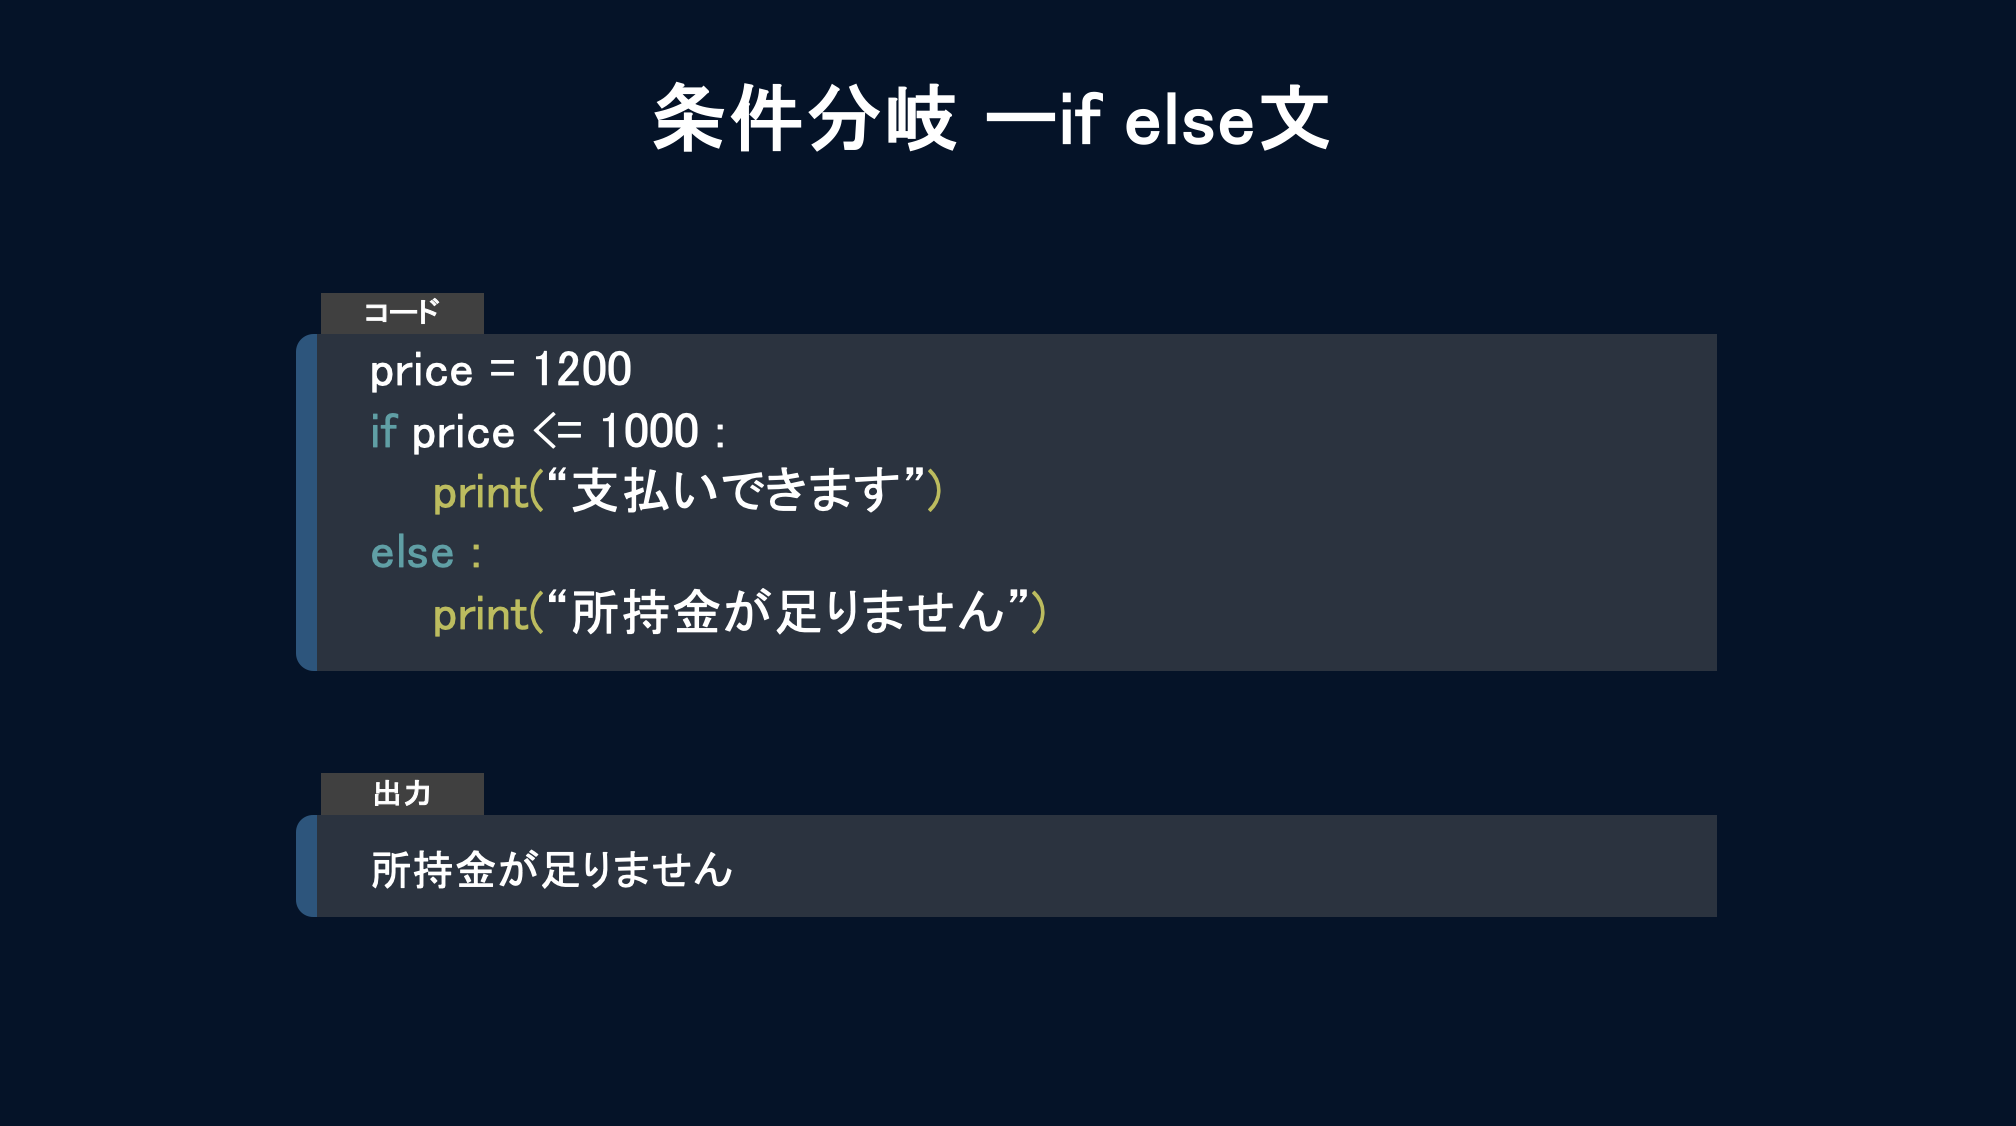

if else文を使うと、条件に合致しなかった場合（つまり`False`だった場合）の処理も合わせて指定することができます。

In [ ]:
#####写経#####
days = 365
if days ==366:
  print("うるう年です")
else:
  print("普通の年です")

普通の年です


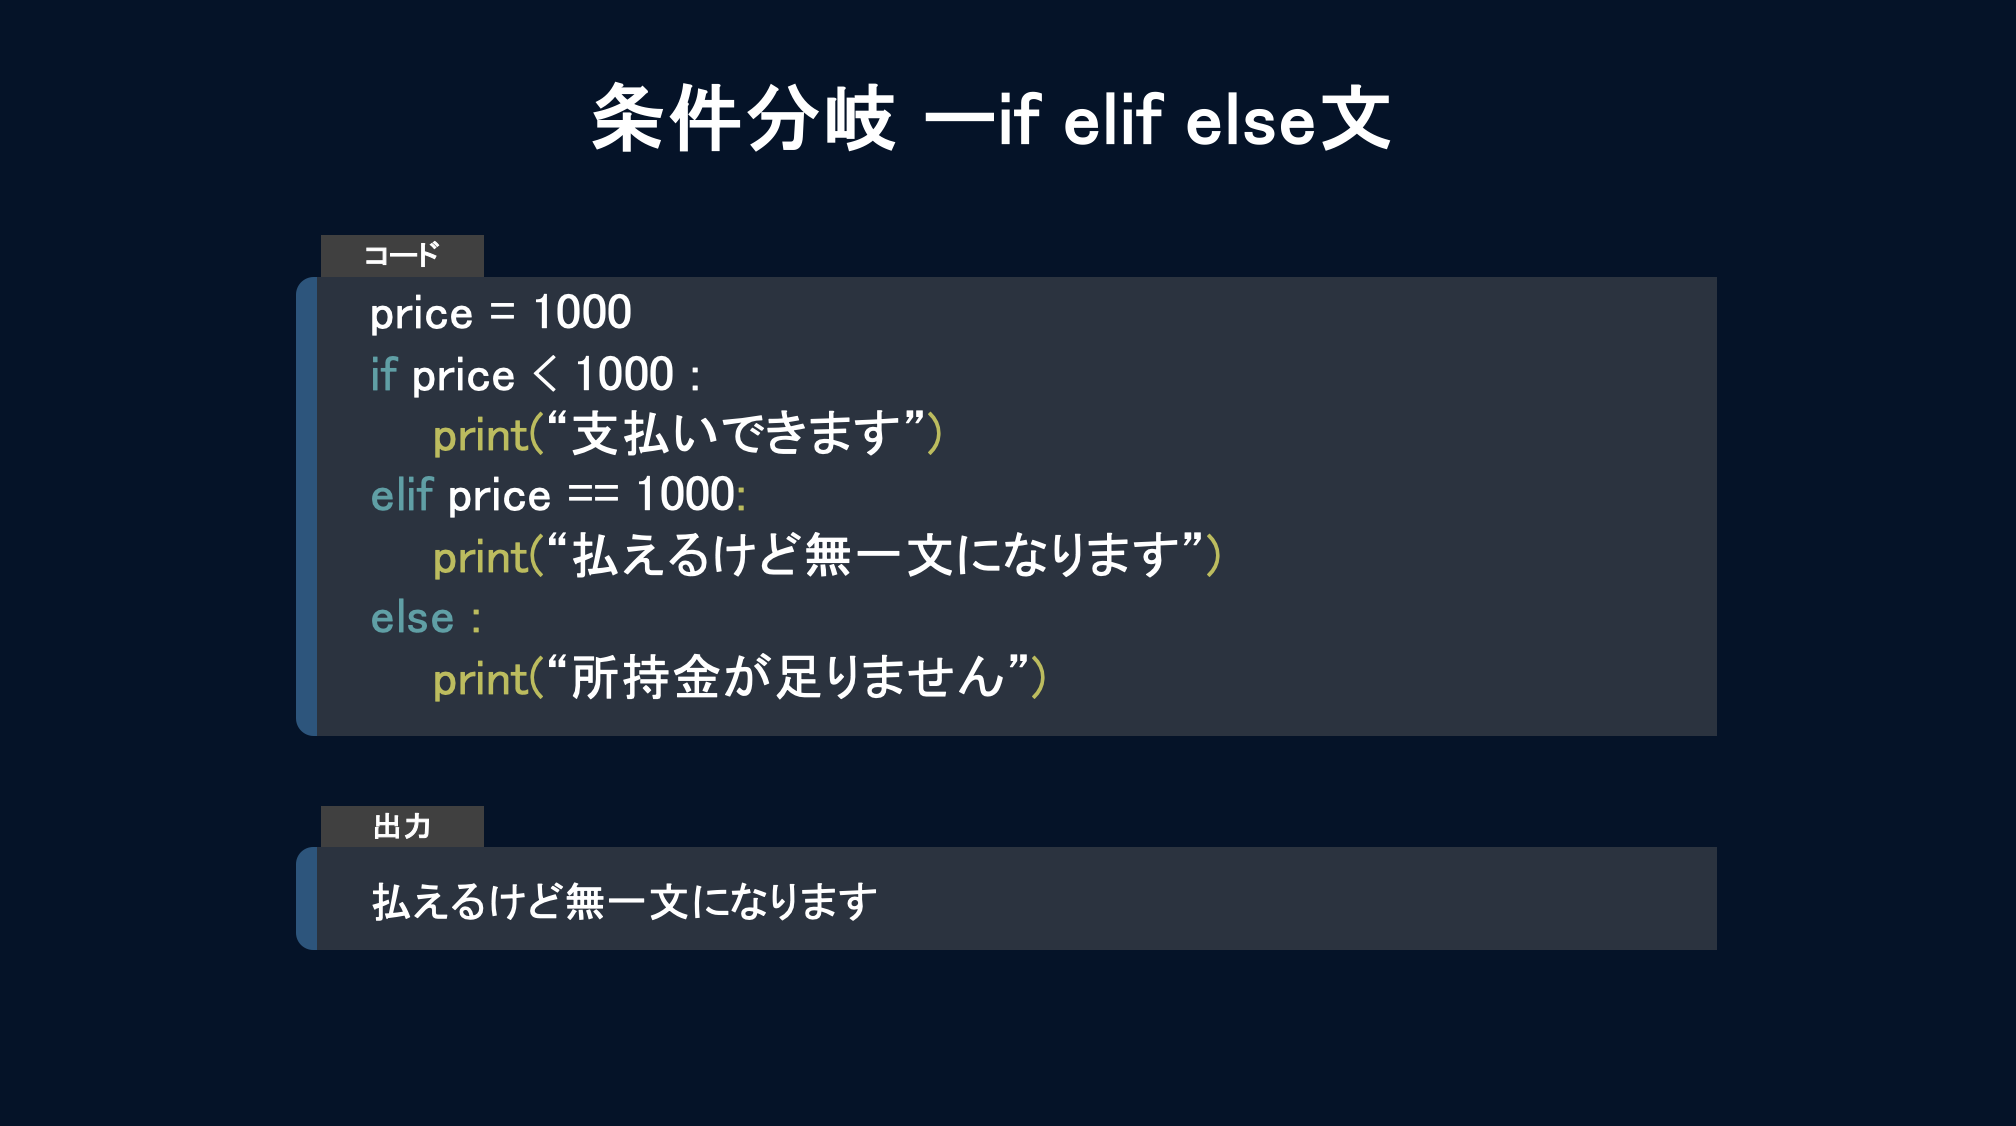

if elif else文を使うと、条件を細かく分ける事ができます。<br>
elifの続きには、ifの続きの時と同じように、`True`または`False`を返す条件判定文を書きます。

In [ ]:
#####写経#####
score = 67
if score < 50:
  print("赤点です")
elif score < 80:
  print("B評価です")
elif score < 90:
  print("A評価です")
else:
  print("S評価です")

B評価です


 ### <font color=#0e89b2>◆練習問題</font>

整数`num`が偶数か奇数かを判定するコードを書いてください。<br>
なお、割り算の余りの計算には、`%`と使います。<br>
例えば、`6%4`を実行すると`2`が出力されます。

解答

In [ ]:
num = 15

if num % 2 == 0:
    print("偶数")
else:
    print("奇数")

奇数


 ### <font color=#0e89b2>(2) 条件分岐（複数条件）</font>

`if (条件式) and (条件式)`や`if (条件式) or (条件式)`のように、論理演算子`and`と`or`を使うと、<br>
複数の条件を組み合わせて判定することができます。<br>
<br>
例えばこちらの例を見てみましょう。<br>
気温が25度以上でかつ湿度60%以上(0.6以上)であれば「蒸し暑いです」<br>
気温は25度以上でも湿度が60%未満であれば「カラッとしています」<br>
を出力するプログラムです。

In [ ]:
temp = 26
hum = 0.8

if temp >= 25 and hum >= 0.6:
  print("蒸し暑いです")
elif temp >= 25 and hum < 0.6:
  print("カラッとしています。")

蒸し暑いです


こちらは、数学か理科のうち、少なくとも一方の点数が80点以上であれば、<br>
「理数系の才能があります」と出力するプログラムです。

In [ ]:
math = 80
science = 92

if math >= 80 or scienece >= 80:
  print("理数系の才能があります")

理数系の才能があります


 ### <font color=#0e89b2>◆練習問題</font>

あなたはテーマパークの入場券発行システムを開発しています。<br>
入場料は年齢と時間帯によって異なります。<br>
以下の条件に基づいて入場料を計算するプログラムを作成してください。


* 年齢が12歳以下または65歳以上の場合、基本入場料は5,000円です。
* 上記に該当しない年齢の場合、基本入場料は8,000円です。
* 17時以降に入場する場合（年齢に関わらず）、入場料が半額になります。

条件
* 年齢は`age`という変数、入場時刻は`enter_time`という変数で定義しましょう。

解答

In [ ]:
age = 24
enter_time = 17

# 入場料の初期値
fee = 1800

# 入場料計算
if age <= 12 or age >= 65:
    fee = 5000
else:
    fee = 8000

# 15時以降の割引適用
if enter_time >= 17:
    fee /= 2

fee

4000.0

 ### <font color=#0e89b2>◆実装</font>

それでは感染シミュレーションモデルの実装に戻っていきます。<br>
ここでは、このセクションで学んだ条件分岐の知識を活かして、<br>
「エージェントが歩いて壁に当たったら方向転換する」処理を実装していきます。<br>
<br>
まず、エージェントが壁に当たった時の挙動を確認しておきます。

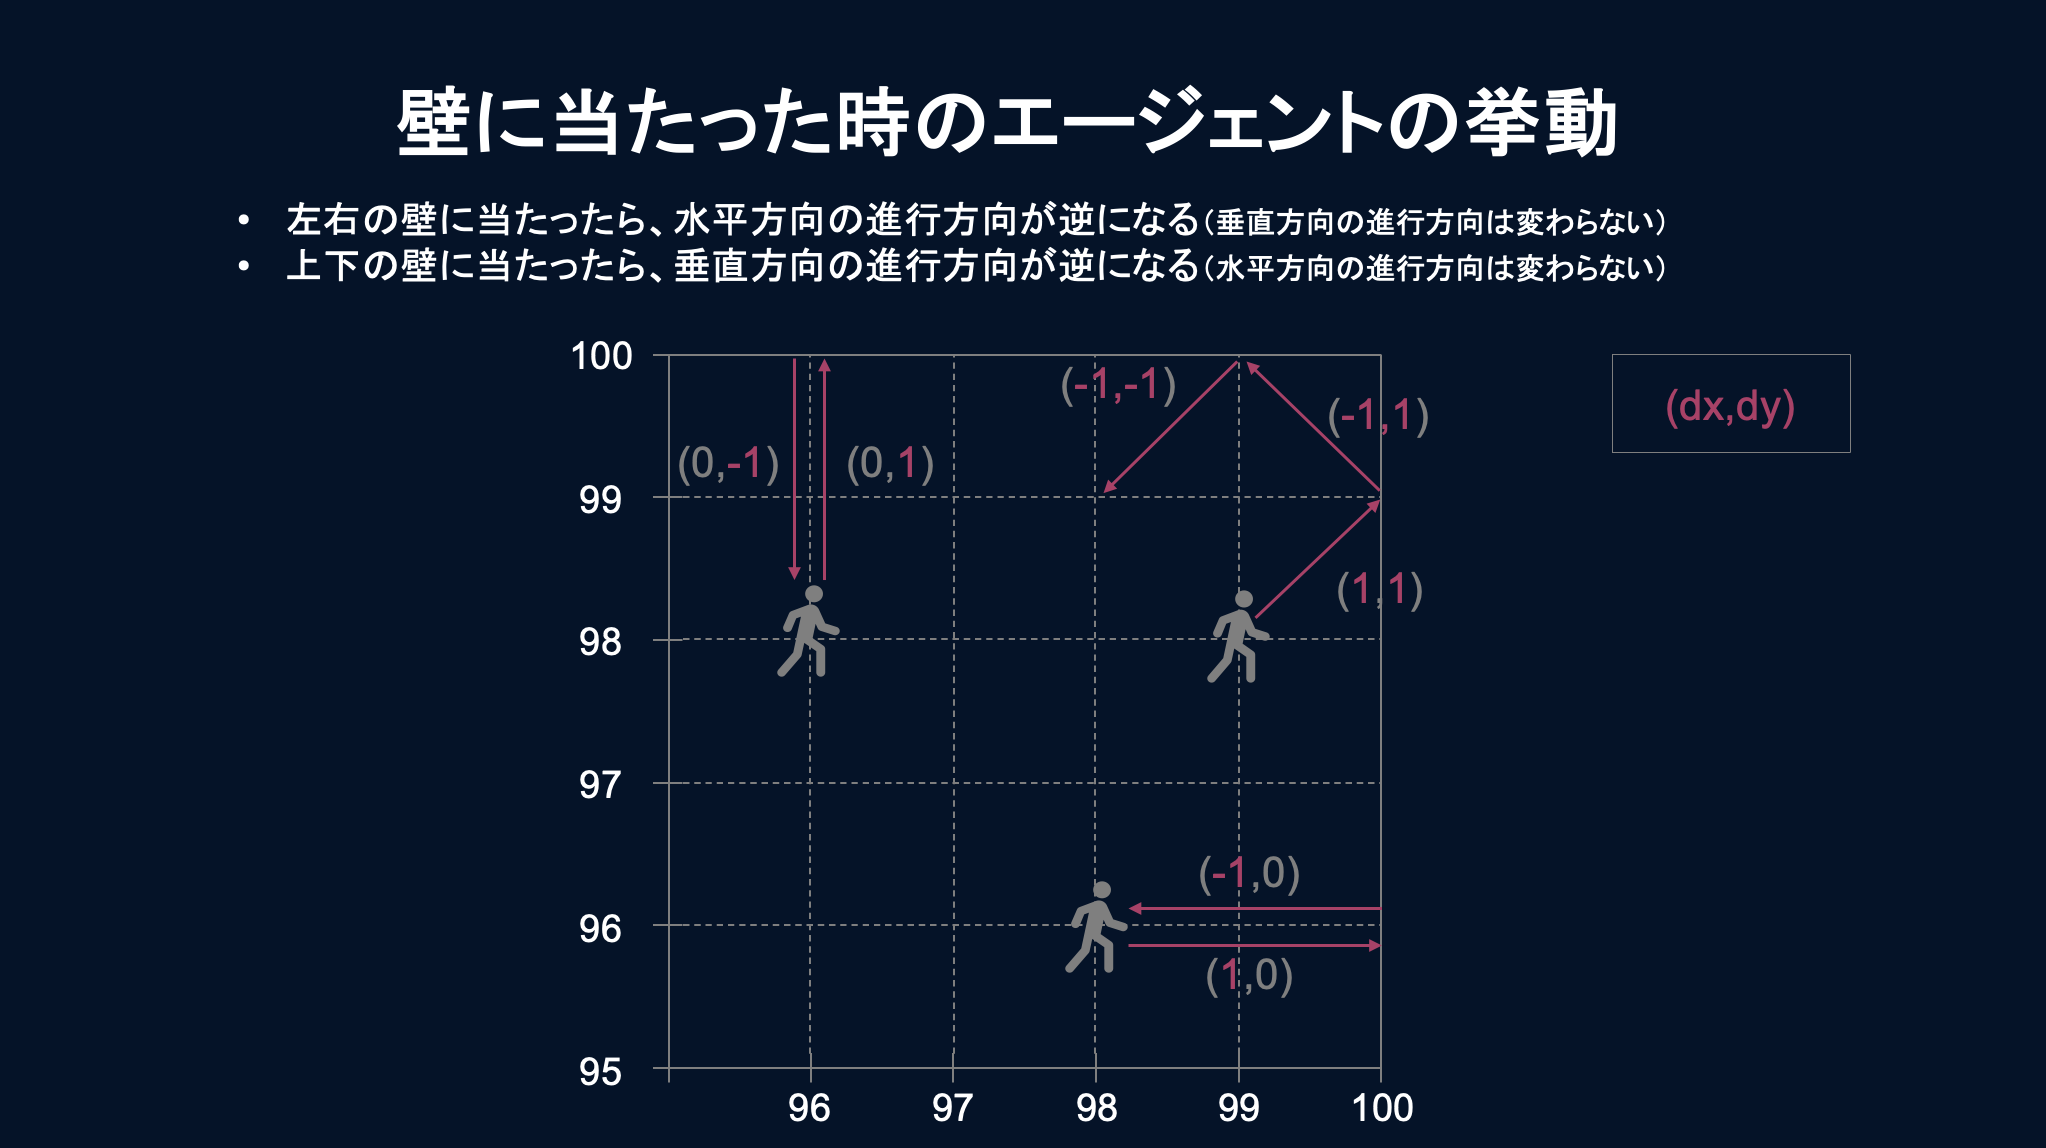

(1) 図の右上のエージェントの挙動を正しく実装しましょう。<br>
3歩歩かせてみて、その通過経路を描画してください。図と同じような経路になっていればOKです。<br>
条件
* エージェントの初期位置は、座標`(99, 98)`とします。
* エージェントのデフォルトの進行方向は、`(1,1)`とします。
* これまで同様、エージェントの位置と進行方向は辞書で管理してください。
* 歩かせる歩数は3歩とします。（つまり現在地も含めると、4つの足跡が描画されます）
* 描画する範囲は、`xlim(95, grid_size)`、`ylim(95, grid_size)`とします。<br>
* エージェントの現在地を示す`agent["x"]`と`agent["y"]`を使って、壁にぶつかっているかどうかを判定してください。

完成イメージはこちらです。

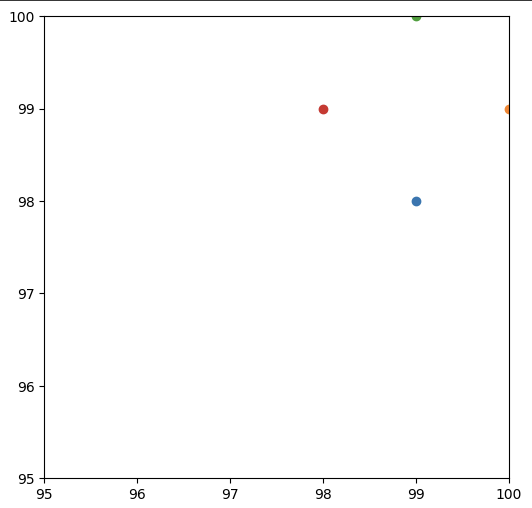

実装例

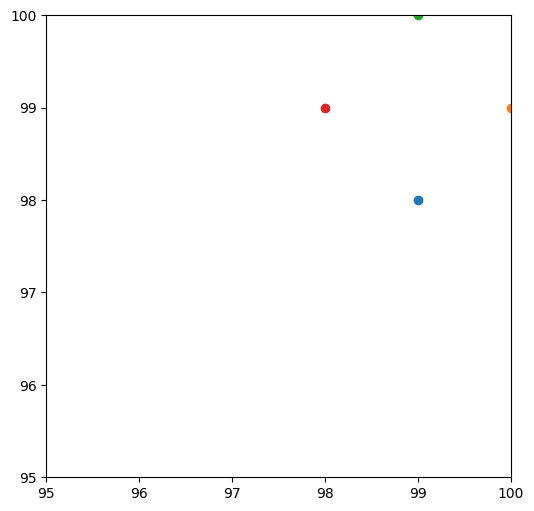

In [ ]:
agent = {"x":99, "y":98, "dx":1, "dy":1}
grid_size = 100

#キャンバスの描画
plt.figure(figsize=(6,6))
plt.xlim(95, grid_size)
plt.ylim(95, grid_size)
plt.scatter(agent["x"], agent["y"]) #現在地の描画

#エージェントを歩かせる
steps = 3
for i in range(steps):
  #壁にぶつかっていたら、反対方向に進路を変更
  if agent['x'] == 0 or agent['x'] == grid_size:
      agent['dx'] *= -1
  if agent["y"] == 0 or agent["y"] == grid_size:
      agent['dy'] *= -1

  #移動
  agent['x'] += agent['dx'] #エージェントの位置（x座標）を更新
  agent['y'] += agent['dy'] #エージェントの位置（y座標）を更新

  #移動が終わった後の現在地描画
  plt.scatter(agent["x"], agent["y"])

(2) 今度は、エージェントの現在地、進行方向をランダムに生成した上で、200歩歩かせてみましょう。<br>
先ほどは街の右角の一部のみを描画していましたが、今度は街全体を描画します。<br>
完成イメージはこちらです。

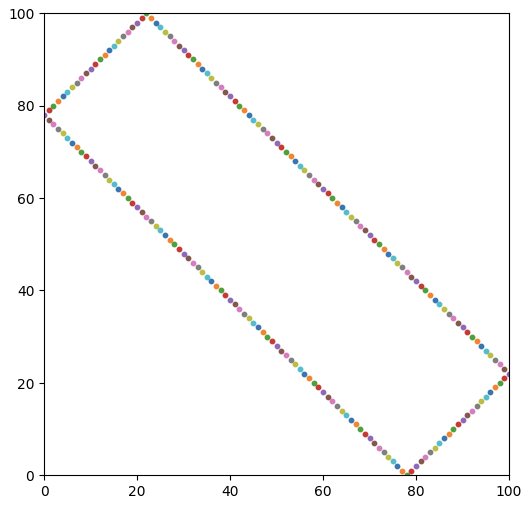

実装例

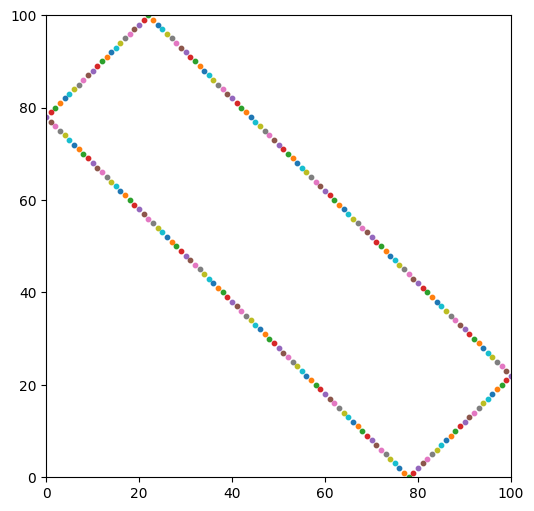

In [ ]:
grid_size = 100

agent = {}
agent["x"] = random.randint(1, grid_size-1)
agent["y"] = random.randint(1, grid_size-1)
agent["dx"] = random.choice([-1, 0, 1])
agent["dy"] = random.choice([-1, 0, 1])

#キャンバスの描画
plt.figure(figsize=(6,6))
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)

#エージェントを歩かせる
steps = 200
for i in range(steps):
  #壁にぶつかっていたら、反対方向に進路を変更
  if agent['x'] == 0 or agent['x'] == grid_size:
      agent['dx'] *= -1
  if agent["y"] == 0 or agent["y"] == grid_size:
      agent['dy'] *= -1

  #移動
  agent['x'] += agent['dx'] #エージェントの位置（x座標）を更新
  agent['y'] += agent['dy'] #エージェントの位置（y座標）を更新

  #移動が終わった後の現在地描画
  plt.scatter(agent["x"], agent["y"], s=10)

 ## <font color=#0e89b2>2.4 アニメーション化する</font>

 ### <font color=#0e89b2>(1) 関数</font>

ここでは、「関数」という概念について学びます。<br>
関数とは、決まった処理をまとめたプログラムの塊です。<br>
例えば、`print()`は「文字を出力する」という処理をまとめて1行で呼び出せるようにした関数ですし、<br>
`plt.scatter()`も「散布図を描画する」という処理をまとめて1行で呼び出せるようにした関数です。<br>
<br>
関数には、`print()`や`sum()`のように事前にPython内で準備されているものもあれば、<br>
新しく自分で作ることもできます。<br>
<br>
ここでは、自分で関数を作成してみましょう。<br>
まずは、実行すると`hello`と出力するだけの、めちゃくちゃ簡単な関数を作成してみます。

In [ ]:
#####写経#####
def say_hello():
  print("hello")

In [ ]:
#####写経#####
say_hello()

hello


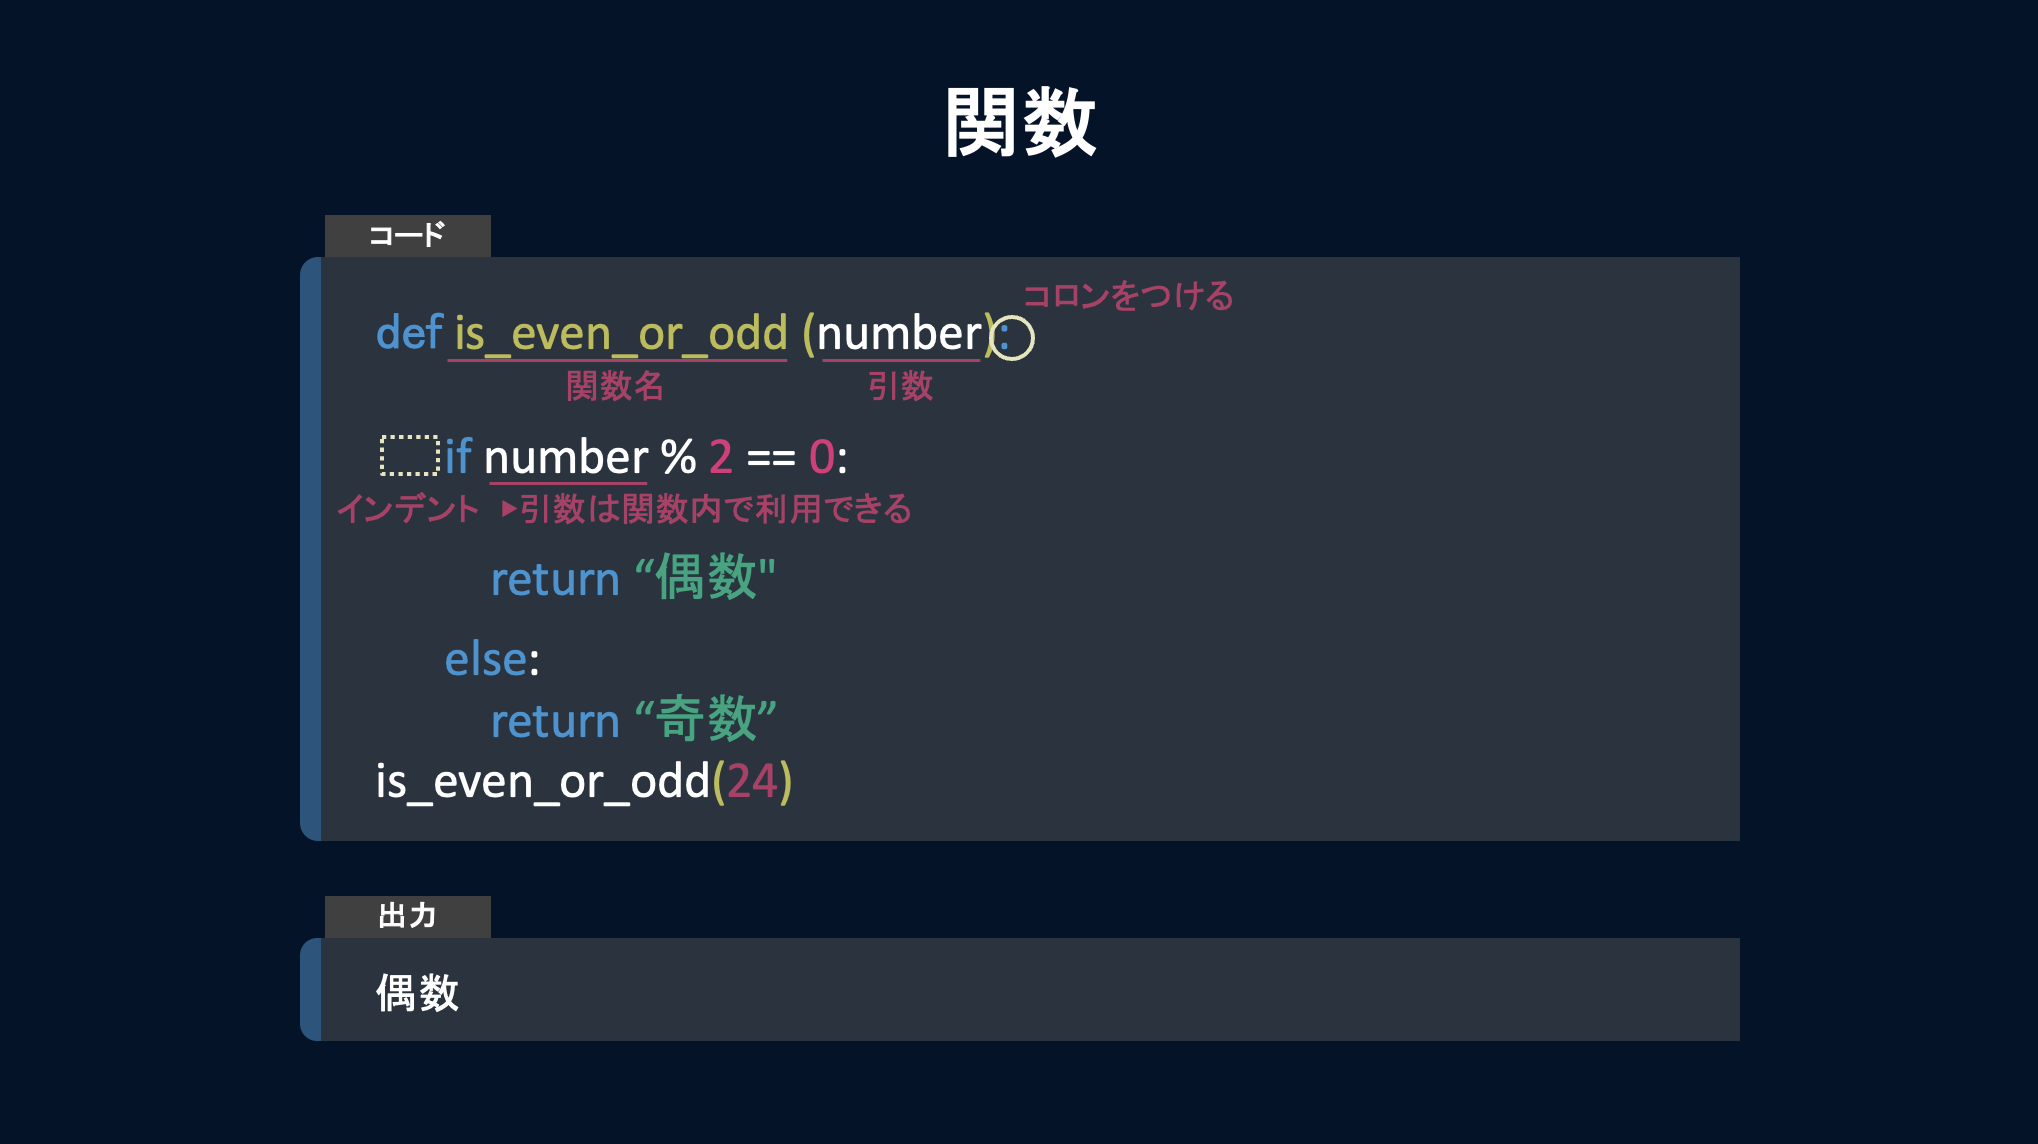

In [ ]:
#####写経#####
def beatles(your_word):
  if your_word == "goodbye":
    print("hello")

In [ ]:
#####写経#####
beatles("goodbye")

hello


引数は2つ以上指定することもできます。

In [ ]:
#####写経#####
def sensible(temp, hum):
  if temp >= 25 and hum >= 0.6:
    print("蒸し暑いです")
  elif temp >= 25 and hum < 0.6:
    print("カラッとしています。")

In [ ]:
#####写経#####
sensible(26, 0.8)

蒸し暑いです


引数には、リストや辞書など、色々なデータ型を受け取ることができます。

In [ ]:
#####写経#####
company_ls = ["Google", "Apple", "Facebook", "Amazon"]
def gafa(company_ls, initial):
  if initial == "G":
    print(company_ls[0])
  elif initial == "A":
    print(company_ls[1], company_ls[3])
  elif initial == "F":
    print(company_ls[2])

In [ ]:
#####写経#####
gafa(company_ls, "A")

Apple Amazon


 ### <font color=#0e89b2>◆練習問題</font>

BMIを計算する関数を作成してください。<br>
なお、BMIの計算式はこちらです。<br>
`BMI ＝ 体重kg ÷ (身長m)^2`<br>
<br>
2乗は、Pythonでは`3**2`(3の2乗)のように書きます。<br>
引数は、`height_cm`(身長cm)と`weight_kg`(体重kg)を受け取るようにしてください。<br>
関数が完成したら、試しに自分の身長と体重で実行してみましょう。

解答

In [ ]:
def calculate_bmi(height_cm, weight_kg):
  #身長をメートル単位に変換
  height_m = height_cm / 100
  #BMIの計算
  bmi = weight_kg / (height_m ** 2)
  #計算結果を返す
  return bmi

In [ ]:
calculate_bmi(168, 58)

20.549886621315196

ちなみにBMIの基準はこんな感じみたいです。

| BMI値 | 判定 |
|    ---   |    ---     |
|  〜18.5 | 痩せ |
| 18.5〜25 | 標準 |
| 25〜30 | 肥満（1度） |
| 30〜35 | 肥満（2度） |
| 35〜40 | 肥満（3度） |

 ### <font color=#0e89b2>(2) FuncAnimation()とto_jshtml()の使い方</font>

いよいよエージェントの動きをアニメーション化するコードを実装していきます。<br>
ここでは、`matplotlib.animation`の`FuncAnimation()`関数と`to_jshtml()`関数を使用します。<br>
<br>
この`FuncAnimation()`の挙動がなかなか分かりづらいので、丁寧に仕様を確認していきます。<br>

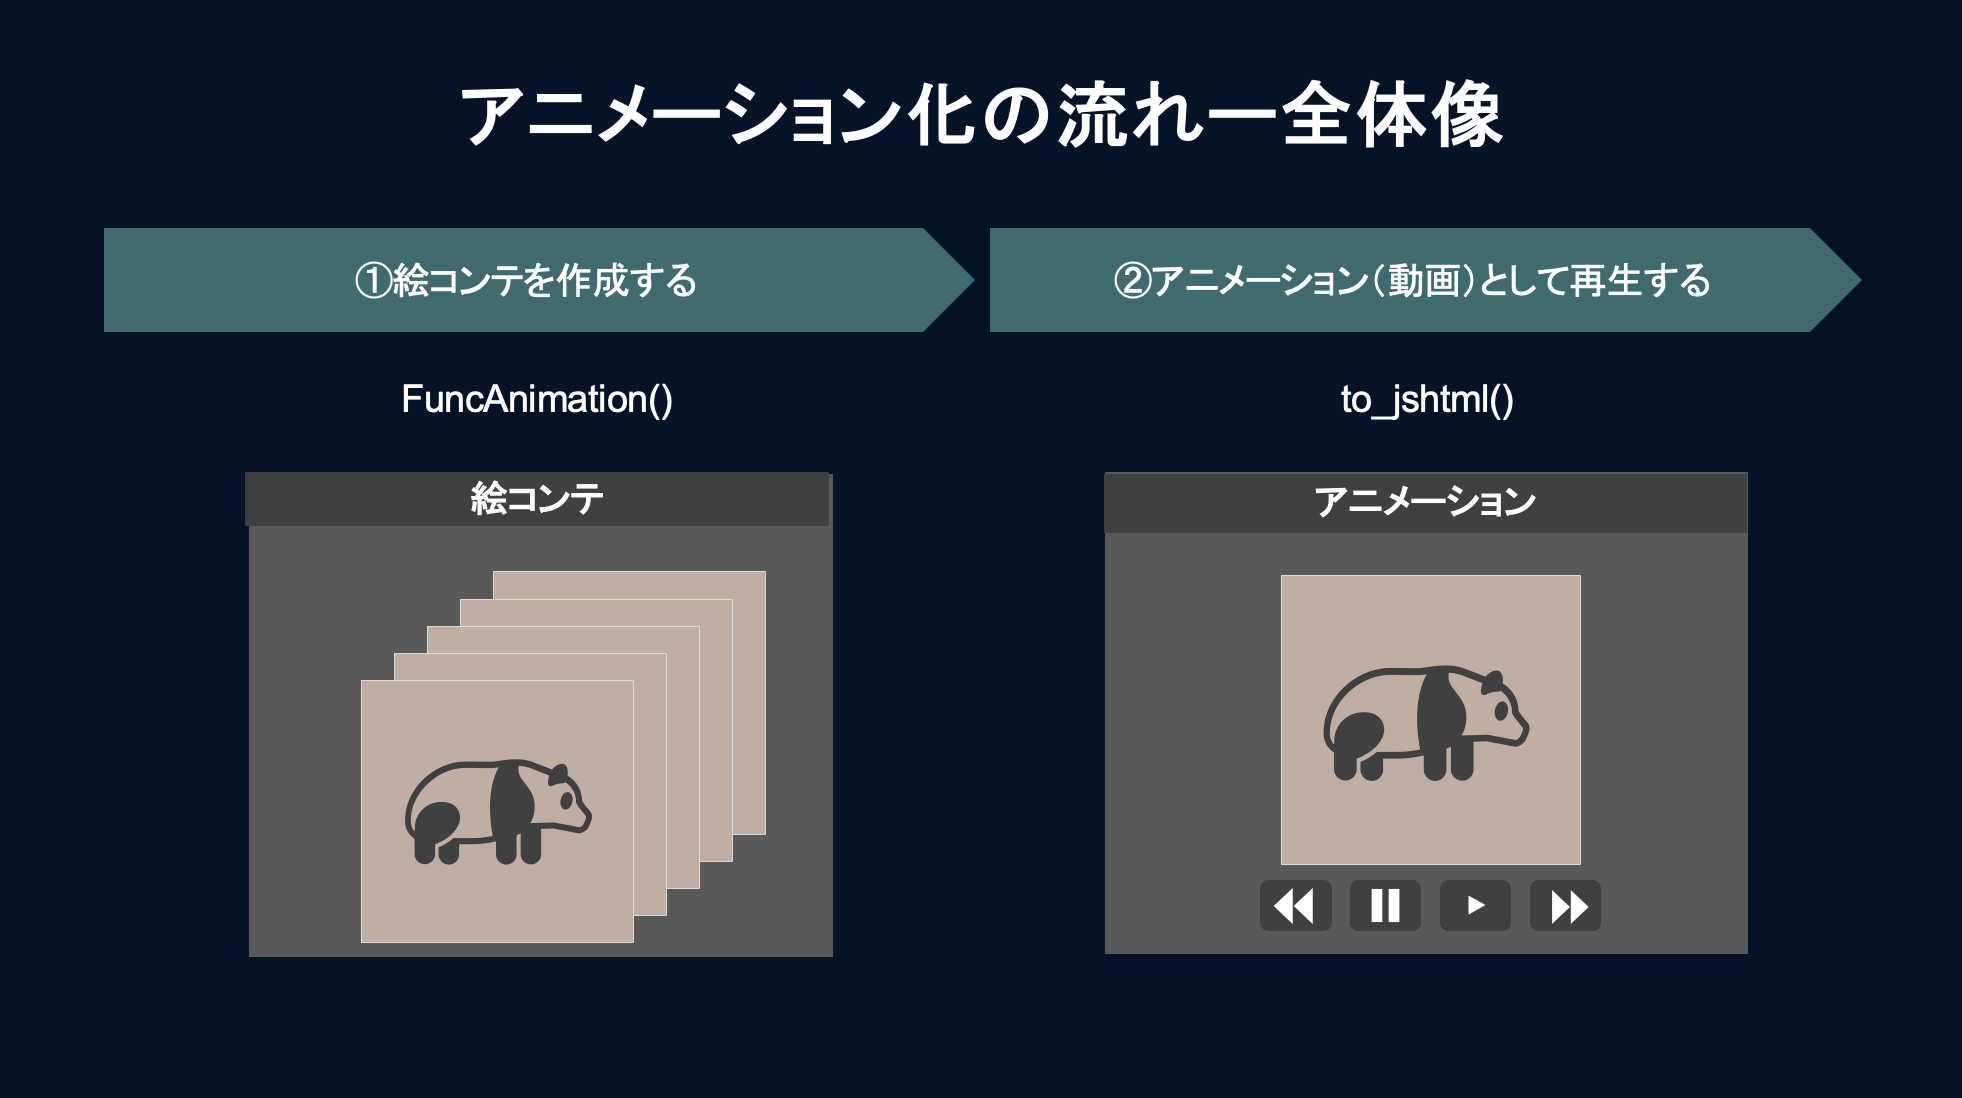

`FuncAnimation()`はアニメーションオブジェクト、いわば「絵コンテ」を作成する関数で、<br>
`to_jshtml()`は、映写機のように絵コンテを再生するための関数です。

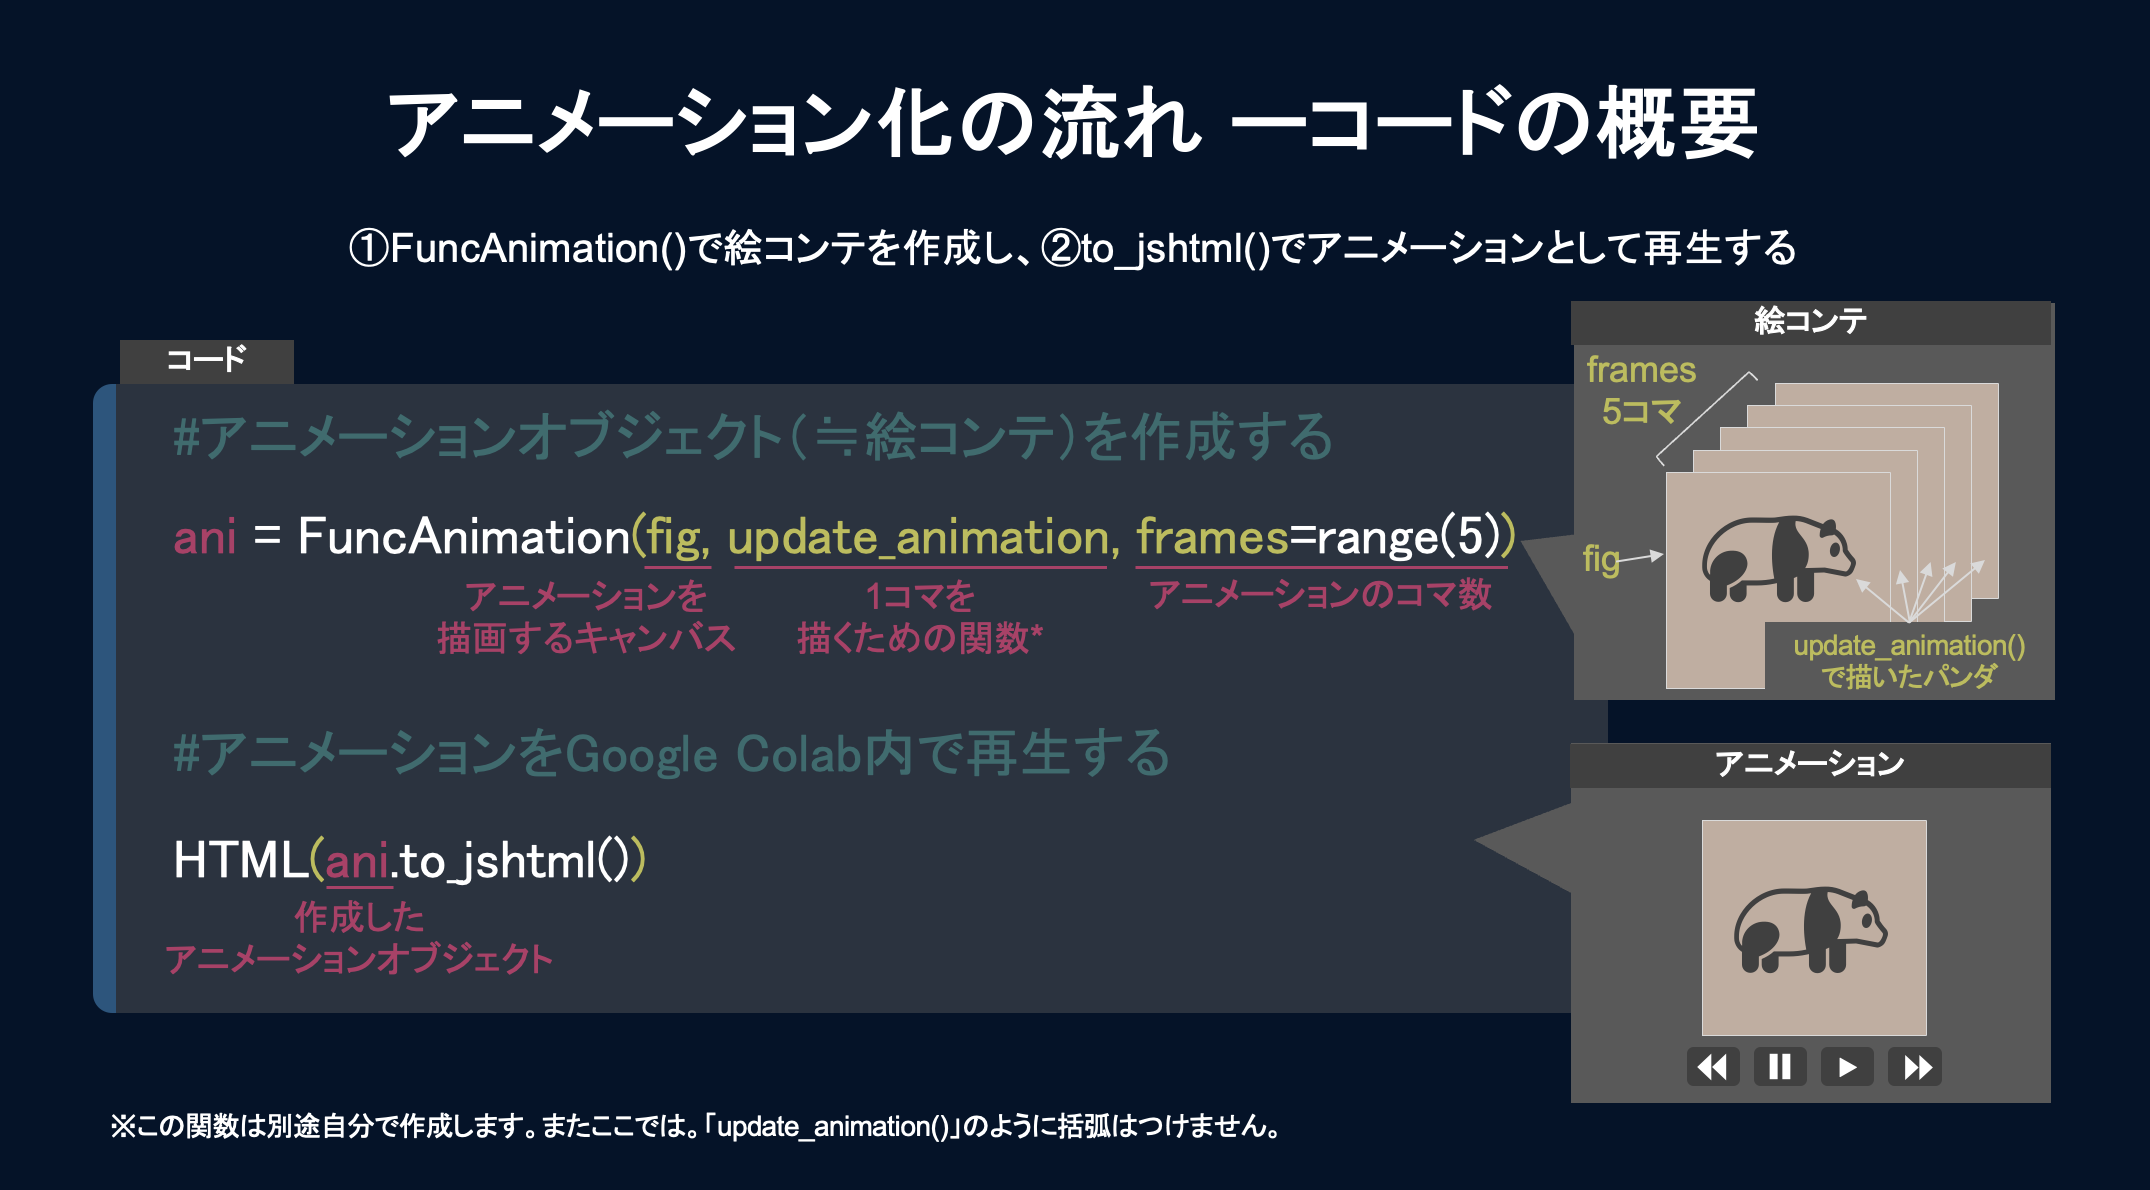

コードの主要な部分はこちらの図の通りで、割とシンプルです。<br>
その他必要なのは、以下2つです。
* `fig`を作成する（`plt.figure()`でOK）
* `update_animation()`の処理内容を書く（作成したいアニメーションによって書く処理内容が異なります）

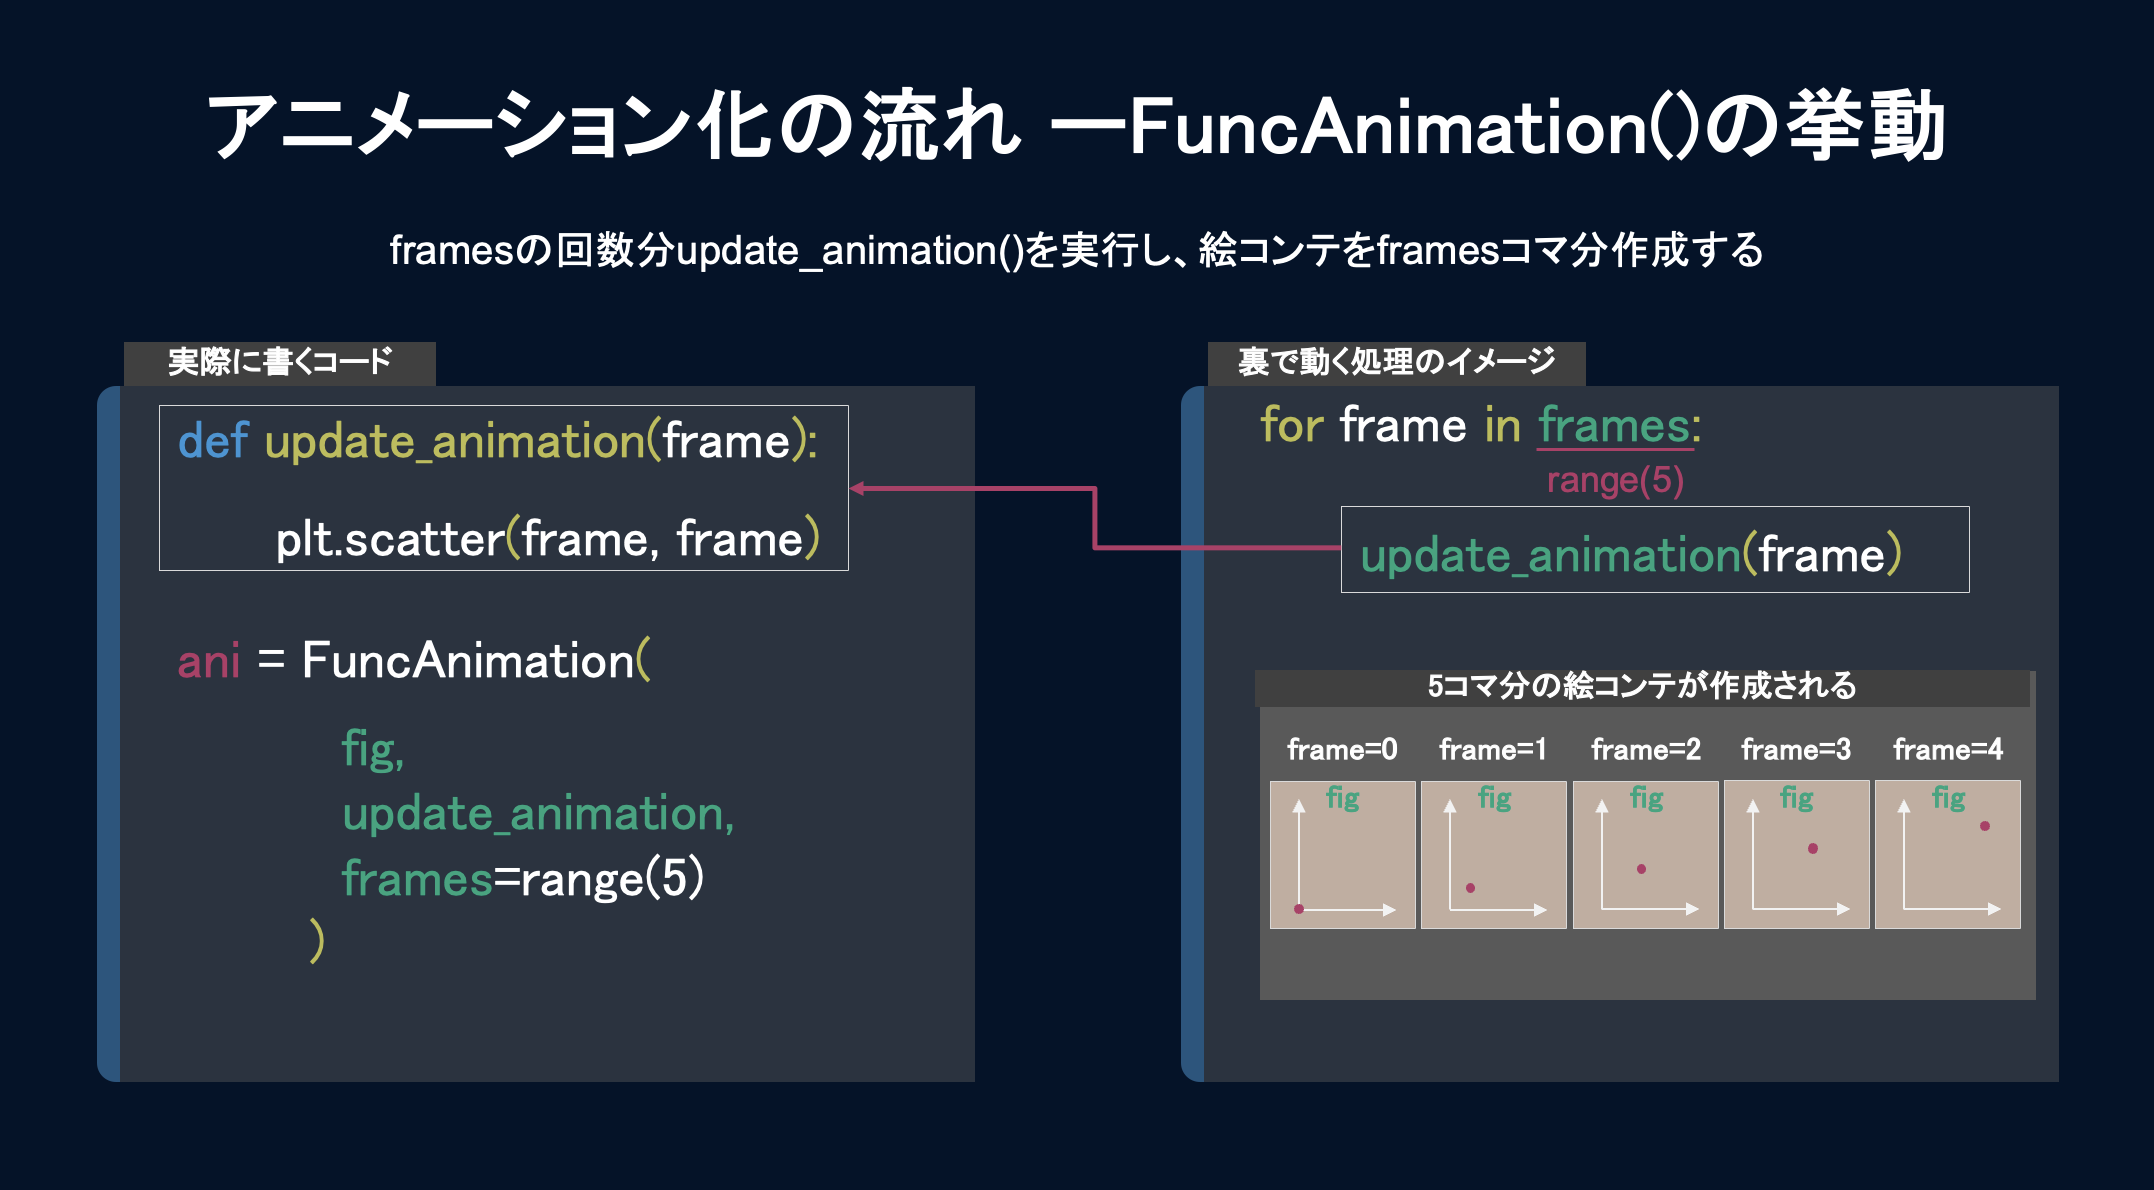

`FuncAnimation()`の挙動は、Python上級者でもぱっと見では理解できないので、上の図で理解しておきましょう。<br>
ポイントとしては、`frames`の回数分絵コンテ作成用の関数`update_animation()`を実行して、<br>
絵コンテが`frames`コマ分作成されるということです。<br>
<br>
それでは、まずはごく簡単なアニメーションを作成してみましょう。

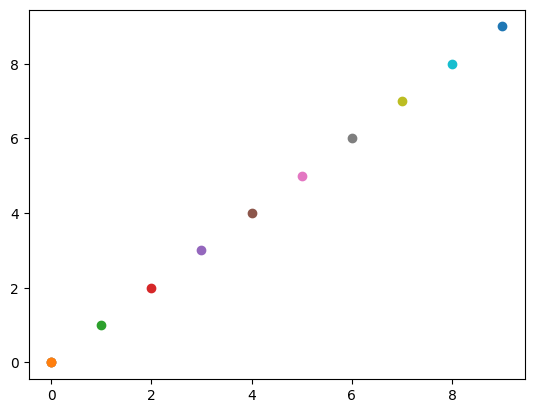

In [ ]:
#####写経#####
def update_animation(frame):
  plt.scatter(frame, frame)

fig = plt.figure()
ani = FuncAnimation(fig, update_animation, frames=range(10))
HTML(ani.to_jshtml())

アニメーションは作成できました！<br>
が、軸が目まぐるしく変わってよく分からない感じになっています。<br>
これを改良するために、軸のスケールを固定するコードを追加しましょう。

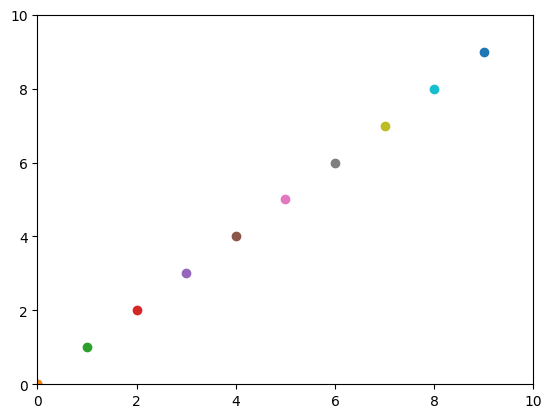

In [ ]:
#####写経#####
def update_animation(frame):
  plt.scatter(frame, frame)

fig = plt.figure()
plt.xlim(0, 10) #追加
plt.ylim(0, 10) #追加
ani = FuncAnimation(fig, update_animation, frames=range(10))
HTML(ani.to_jshtml())

軸は固定されましたが、1個の点が移動していくのではなく、<br>
複数の点が順番に描画されるようなアニメーションになってしまっています。<br>
<br>
これも少し意図とは違うので、さらに修正を加えましょう。<br>
今複数の点が描画されてしまっている原因は、<br>
1コマ前に描画した絵の上に上書きして新しいコマの絵コンテを作ってしまっているためです。<br>
これを解決するためには、コマごとに毎回「前のコマの絵をリセットする」処理を書き加えてあげます。<br>
このリセットのためには、`plt.clf()`(現在の図をクリアする)というコードを書き加えてあげましょう。

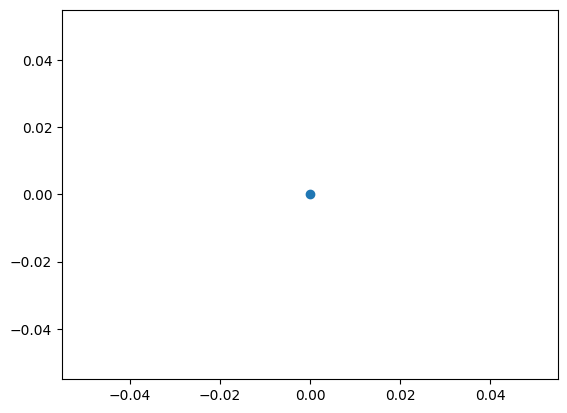

In [ ]:
def update_animation(frame):
  plt.clf() #追加
  plt.scatter(frame, frame)

fig = plt.figure()
plt.xlim(0, 10)
plt.ylim(0, 10)
ani = FuncAnimation(fig, update_animation, frames=range(10))
HTML(ani.to_jshtml())

おっと。<br>
今度は、描かれる点が一つになったのは良いものの、再び軸が目まぐるしく動く仕様になってしまいました。<br>
これは、先ほど書き加えた`plt.clf()`によって、`plt.xlim()`と`plt.ylim()`で設定した軸もリセットされてしまうためです。<br>
<br>
これを解決するためには、`plt.clf()`の処理の後に毎回`plt.xlim()`と`plt.ylim()`で軸を設定し直してあげる仕様にしましょう。

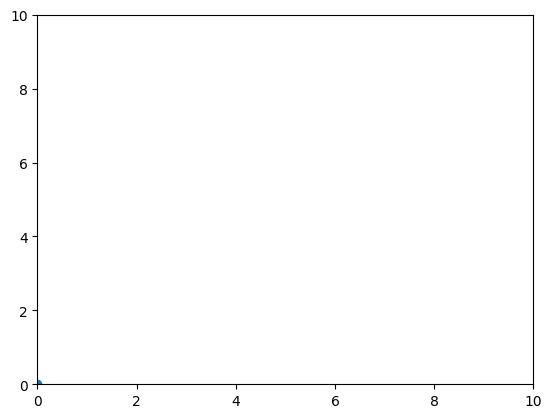

In [ ]:
def update_animation(frame):
  plt.clf() #追加
  plt.xlim(0, 10)
  plt.ylim(0, 10)
  plt.scatter(frame, frame)

fig = plt.figure()
ani = FuncAnimation(fig, update_animation, frames=range(10))
HTML(ani.to_jshtml())

これで意図した挙動になりました。<br>
<br>
最後に、より柔軟にアニメーションを作成できるよう、`update_animation()`に引数を渡すやり方を学びます。<br>
`update_animation()`は最低でも必ず`frame`は引数として受け取るのですが、<br>
他にも引数を追加した場合には、少し癖のある書き方をしなければいけません。


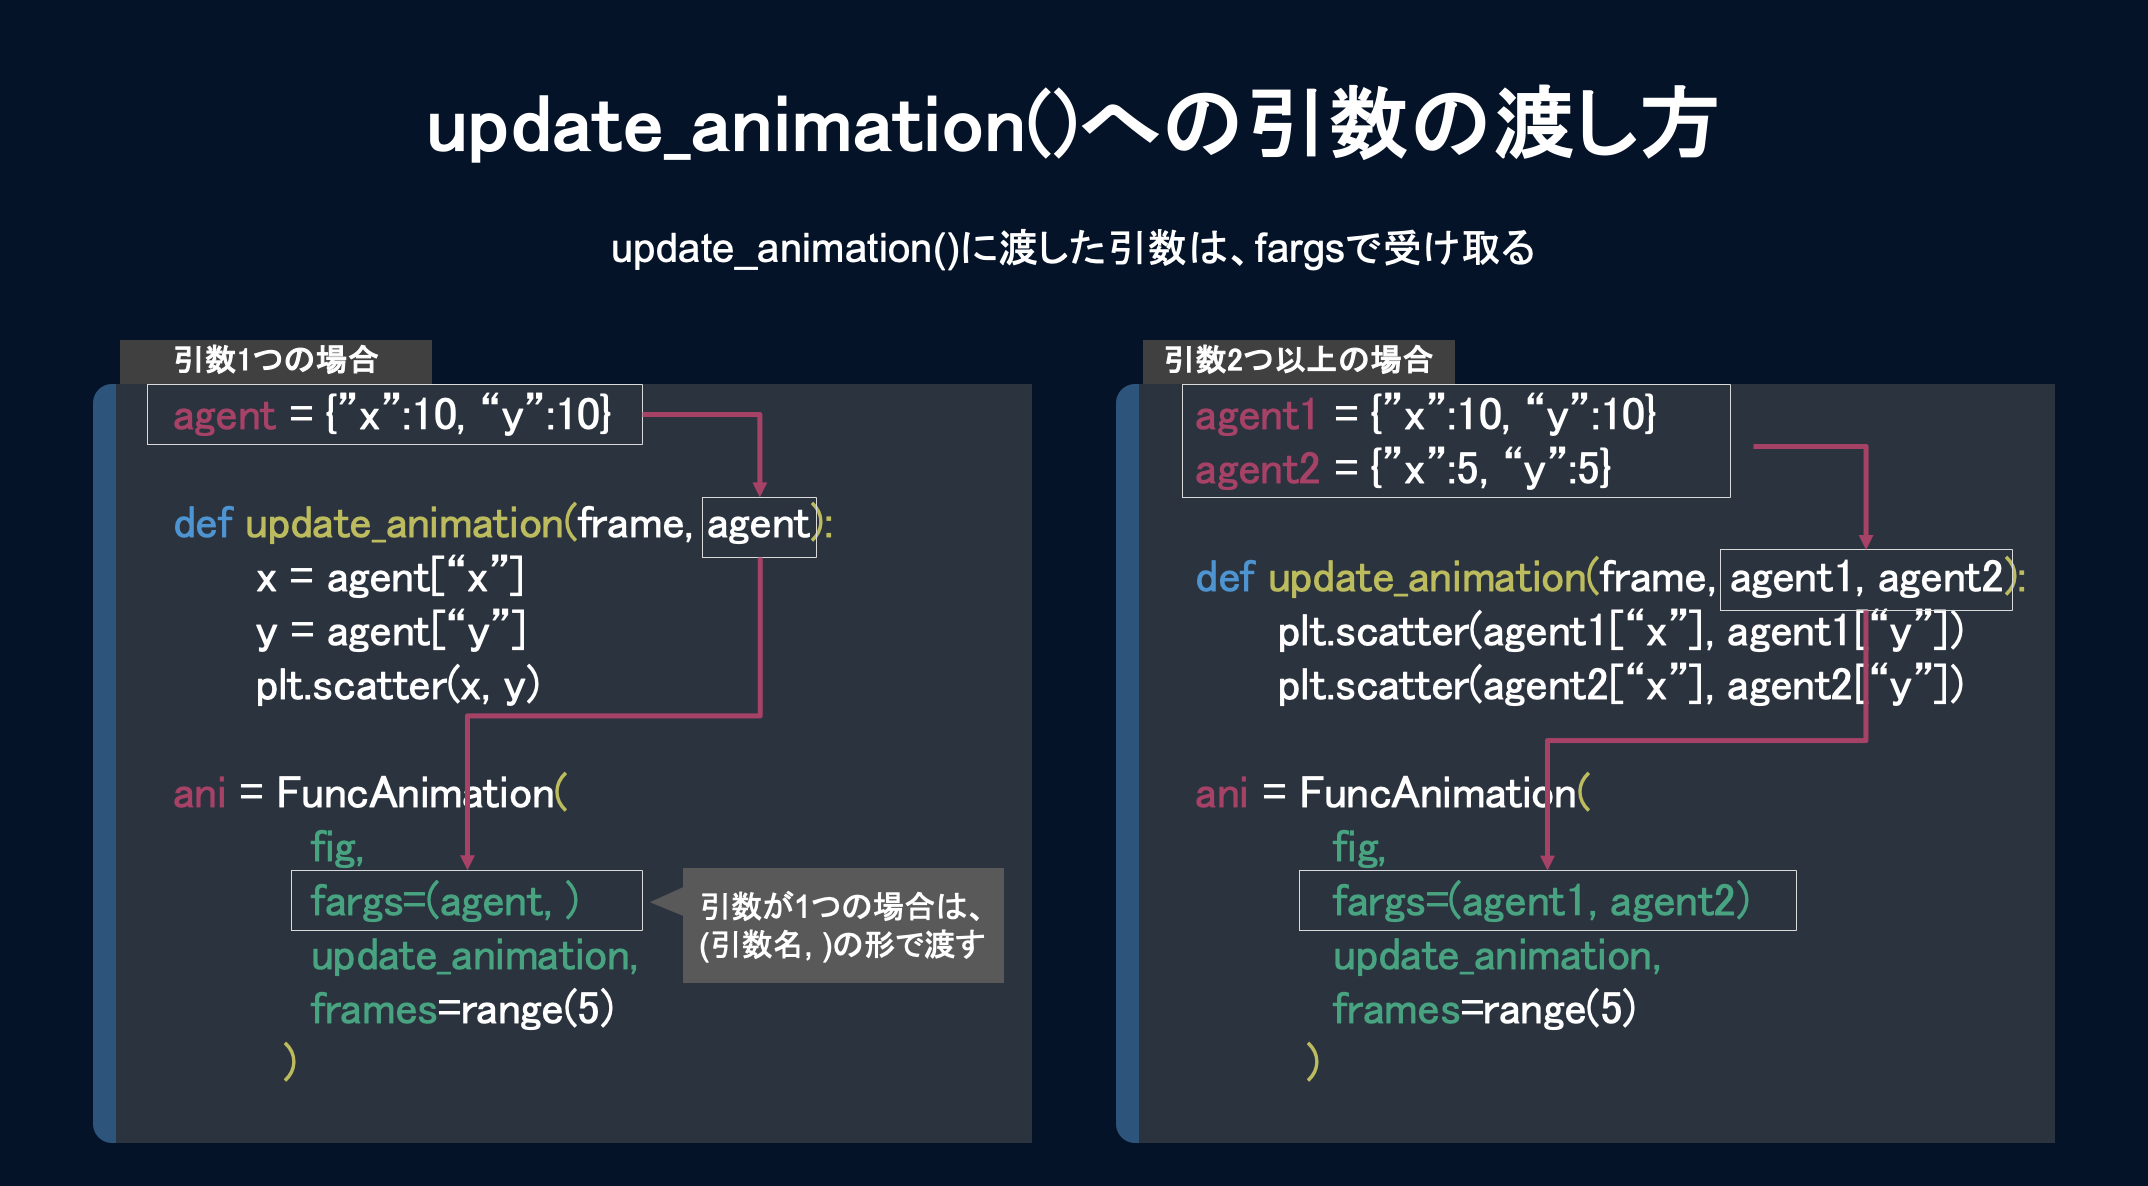

`update_animation()`関数の方には、`frame`に続いて追加したい引数を記入していきます。<br>
そして引数を追加した場合は、`FuncAnimation()`の方にも「この引数を追加したよ」と教えてあげる必要があります。<br>
具体的には、`FuncAnimation()`の引数に`fargs=(追加した引数、追加した引数)`と記入する必要があります。<br>
<br>

例えば下のコードでは、引数にエージェントの初期位置を渡してあげることで、<br>
初期位置が`(2, 2)`のエージェントが水平方向に+1、垂直方向に+1ずつ進む処理を実装しています。<br>

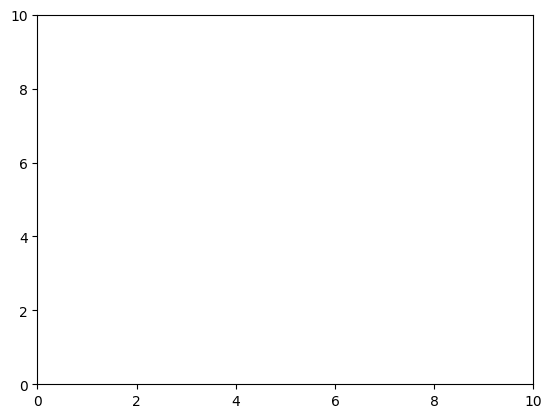

In [ ]:
agent_default = {"x":2, "y":2}
def update_animation(frame, agent):
  plt.clf() #追加
  plt.xlim(0, 10)
  plt.ylim(0, 10)
  plt.scatter(agent["x"], agent["y"])
  agent["x"] += 1
  agent["y"] += 1

fig = plt.figure()
ani = FuncAnimation(fig, update_animation, fargs=(agent_default,), frames=range(10))
HTML(ani.to_jshtml())

 ### <font color=#0e89b2>◆実装</font>

さて、アニメーション化の方法を理解できたところで、シミュレーションモデルの実装に入っていきましょう。<br>
<br>
(1) 2.3で実装した、エージェントが壁にぶつかったら方向転換しながら進む処理を、関数化しましょう。<br>
条件
* 関数名は、`move_agents()`としてください。
* 引数は以下のキーと値を持つ辞書`agent`を受け取ってください。
 * `x`：エージェントの現在地のx座標
 * `y`：エージェントの現在地のy座標
 * `dx`：エージェントの進行方向（水平方向）
 * `dy`：エージェントの進行方向（垂直方向）
* 返り値(`return`で返す値）は、以下のキーと値を持つ辞書`agent`を返してください。
 * `x`：エージェントが1歩移動した後の現在地のx座標
 * `y`：エージェントが1歩移動した後の現在地のy座標
 * `dx`：エージェントの進行方向（水平方向）（方向転換した場合は、方向転換後の進行方向）
 * `dy`：エージェントの進行方向（垂直方向）（方向転換した場合は、方向転換後の進行方向）


※参考として、エージェントの移動の挙動を実装したサンプルコードを掲載しておきます。

In [ ]:
grid_size = 100

agent = {}
agent["x"] = random.randint(1, grid_size-1)
agent["y"] = random.randint(1, grid_size-1)
agent["dx"] = random.choice([-1, 0, 1])
agent["dy"] = random.choice([-1, 0, 1])

#キャンバスの描画
plt.figure(figsize=(6,6))
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)

#エージェントを歩かせる
steps = 200
for i in range(steps):
########################
#####この部分を関数化する#####
########################
  #壁にぶつかっていたら、反対方向に進路を変更
  if agent['x'] == 0 or agent['x'] == grid_size:
      agent['dx'] *= -1
  if agent["y"] == 0 or agent["y"] == grid_size:
      agent['dy'] *= -1

  #移動
  agent['x'] += agent['dx'] #エージェントの位置（x座標）を更新
  agent['y'] += agent['dy'] #エージェントの位置（y座標）を更新

  #移動が終わった後の現在地描画
  plt.scatter(agent["x"], agent["y"], s=10)
########################
#####関数化する箇所終わり#####
########################

In [ ]:
#関数化


実装例

In [ ]:
def move_agents(agent):
  #壁にぶつかっていたら、反対方向に進路を変更
  if agent['x'] == 0 or agent['x'] == grid_size:
      agent['dx'] *= -1
  if agent["y"] == 0 or agent["y"] == grid_size:
      agent['dy'] *= -1

  #移動
  agent['x'] += agent['dx'] #エージェントの位置（x座標）を更新
  agent['y'] += agent['dy'] #エージェントの位置（y座標）を更新
  return agent

(2) 一人のエージェントが、壁にぶつかったら方向転換しながら、40歩分移動し続けるアニメーションを作成しましょう。<br>
条件
* 壁に当たった時の挙動は、(1)で作成した関数を使用してください。
* エージェントの初期位置と進行方向は、以下の設定にしてください。
 * `x：12`
 * `y：6`
 * `dx：1`
 * `dy：１`
* 街の広さとコマ数は、それぞれ以下の変数名と値で設定してください。
 * `grid_size = 20 `
 * `steps = 40`

実装例

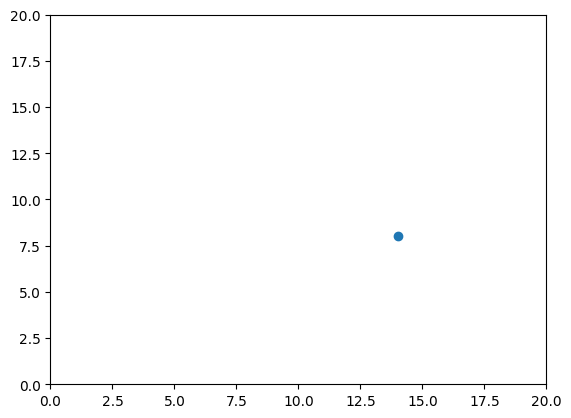

In [ ]:
def update_animation(frame, agent):
  # 次の移動先の決定
  agent = move_agents(agent)

  plt.clf()
  plt.xlim(0, grid_size)
  plt.ylim(0, grid_size)
  plt.scatter(agent["x"], agent["y"])

# グリッドサイズとステップ数の定義
grid_size = 20
steps = 40
# エージェントの初期位置
agent = {"x": 12, "y": 6, "dx": 1, "dy": 1}

# アニメーションの作成
fig = plt.figure()
ani = FuncAnimation(fig, update_animation, fargs=(agent,), frames=range(steps))

# アニメーションの表示
HTML(ani.to_jshtml())

これでエージェントの挙動とそのアニメーション化まで実装が完了しました。<br>
次のLevel3では、感染やマスク着用の処理を実装していきます。